# **PROJECT 1 — REPRESENTASI DAN PREPROSES DATA**
## KELOMPOK 7 · KAL TIF-D

| No | Nama | NIM |
|----|------|-----|
| 1 | Muhammad Fakhri Aldiansyah | 245150201111049 |
| 2 | Jason Manuel | 245150201111050 |
| 3 | Putri Griselda Sonandi | 245150207111036 |

**Dosen:** Dr. Candra Dewi, S.Kom., M.Sc.  
**Dataset:** Chronic Kidney Disease (CKD)

---
## Alur Notebook
1. Import Library  
2. Load & Inspeksi Data Awal  
3. Data Cleaning (Drop Fitur Noise)  
4. Klasifikasi Tipe Fitur  
5. Exploratory Data Analysis (EDA)  
   - 5.1 Integritas Data (Missing Value)  
   - 5.2 Statistik Deskriptif  
   - 5.3 Distribusi Variabel Target (Class Imbalance)  
   - 5.4 Distribusi Fitur Numerik (Histogram + KDE)   
   - 5.5 Pair Plot Fitur Utama  
6. Data Preprocessing  
   - 6.1 Penanganan Outlier (IQR Capping)  
   - 6.2 Normalisasi Z-Score (StandardScaler)  
7. Validasi Data Akhir & Simpan Output

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## 2. Load & Inspeksi Data Awal

In [2]:
df = pd.read_csv('CKD.csv', sep=';')
print(f"Dimensi Data Mentah : {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"\nDaftar Kolom ({len(df.columns)} total):")
print(df.columns.tolist())

Dimensi Data Mentah : 1659 baris x 54 kolom

Daftar Kolom (54 total):
['PatientID', 'Age', 'Gender', 'Ethnicity', 'SocioeconomicStatus', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryKidneyDisease', 'FamilyHistoryHypertension', 'FamilyHistoryDiabetes', 'PreviousAcuteKidneyInjury', 'UrinaryTractInfections', 'SystolicBP', 'DiastolicBP', 'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR', 'ProteinInUrine', 'ACR', 'SerumElectrolytesSodium', 'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium', 'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'ACEInhibitors', 'Diuretics', 'NSAIDsUse', 'Statins', 'AntidiabeticMedications', 'Edema', 'FatigueLevels', 'NauseaVomiting', 'MuscleCramps', 'Itching', 'QualityOfLifeScore', 'HeavyMetalsExposure', 'OccupationalExposureChemicals', 'WaterQuality', 'MedicalCheckupsFrequency'

In [3]:
df.head()

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,...,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,...,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,...,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,...,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,...,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,...,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


## 3. Data Cleaning — Drop Fitur Noise

Kolom **PatientID** dan **DoctorInCharge** dieliminasi karena:
- Bersifat identifier unik, tidak memiliki nilai prediktif terhadap Diagnosis.
- `DoctorInCharge` bertipe string kategorikal dengan nilai konstan (`"Confidential"`), sehingga tidak memberikan varians informasi apapun.
- Mempertahankan kedua kolom ini hanya akan menambah noise pada algoritma Machine Learning.

In [4]:
COLS_TO_DROP = ['PatientID', 'DoctorInCharge']
df_clean = df.drop(columns=COLS_TO_DROP)

print(f"Dimensi sebelum drop : {df.shape[1]} kolom")
print(f"Dimensi setelah drop : {df_clean.shape[1]} kolom")
print(f"Kolom yang dihapus   : {COLS_TO_DROP}")

Dimensi sebelum drop : 54 kolom
Dimensi setelah drop : 52 kolom
Kolom yang dihapus   : ['PatientID', 'DoctorInCharge']


## 4. Klasifikasi Tipe Fitur

Dataset memiliki dua kelompok fitur selain variabel target:

| Tipe | Kriteria | Perlakuan |
|------|----------|-----------|
| **Biner / Kategorikal** | `nunique == 2`, dikodekan 0/1 (sudah numerik dari sumber) | Dipertahankan tanpa transformasi skala |
| **Kontinu / Numerik** | `nunique > 2` dan bukan `Diagnosis` | Akan dinormalisasi dengan StandardScaler |

> **Catatan:** Kolom seperti `Ethnicity`, `SocioeconomicStatus`, dan `EducationLevel` memiliki lebih dari 2 nilai unik (ordinal), sehingga dimasukkan ke kelompok kontinu untuk ikut dinormalisasi.

In [5]:
binary_cols = [
    col for col in df_clean.columns
    if col != 'Diagnosis' and df_clean[col].nunique() == 2
]

continuous_cols = [
    col for col in df_clean.columns
    if col not in binary_cols and col != 'Diagnosis'
]

print(f"Fitur Biner/Kategorikal  : {len(binary_cols)} fitur")
print(binary_cols)
print()
print(f"Fitur Kontinu/Numerik    : {len(continuous_cols)} fitur")
print(continuous_cols)
print()
print(f"Target Variabel          : Diagnosis")
print(f"Total fitur prediktif    : {len(binary_cols) + len(continuous_cols)} fitur")

Fitur Biner/Kategorikal  : 15 fitur
['Gender', 'Smoking', 'FamilyHistoryKidneyDisease', 'FamilyHistoryHypertension', 'FamilyHistoryDiabetes', 'PreviousAcuteKidneyInjury', 'UrinaryTractInfections', 'ACEInhibitors', 'Diuretics', 'Statins', 'AntidiabeticMedications', 'Edema', 'HeavyMetalsExposure', 'OccupationalExposureChemicals', 'WaterQuality']

Fitur Kontinu/Numerik    : 36 fitur
['Age', 'Ethnicity', 'SocioeconomicStatus', 'EducationLevel', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR', 'ProteinInUrine', 'ACR', 'SerumElectrolytesSodium', 'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium', 'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'NSAIDsUse', 'FatigueLevels', 'NauseaVomiting', 'MuscleCramps', 'Itching', 'QualityOfLifeScore', 'MedicalCheckupsFrequency', 'Medica

## 5. Exploratory Data Analysis (EDA)

### 5.1 Integritas Data — Pengecekan Missing Value

In [6]:
total_missing = df_clean.isnull().sum().sum()
print(f"Total Missing Value di seluruh dataset : {total_missing}")

Total Missing Value di seluruh dataset : 0


In [7]:
missing_per_col = df_clean.isnull().sum()
if missing_per_col.sum() == 0:
    print(" Dataset bersih — tidak ada missing value sama sekali (kelengkapan 100%).")
    print(" Teknik imputasi (mean/median/KNN) tidak diperlukan.")
else:
    print("Kolom dengan missing value:")
    print(missing_per_col[missing_per_col > 0])

 Dataset bersih — tidak ada missing value sama sekali (kelengkapan 100%).
 Teknik imputasi (mean/median/KNN) tidak diperlukan.


### 5.2 Statistik Deskriptif

Tahapan ini memuat Tabel dalam merangkum ukuran statistik utama untuk **seluruh fitur kontinu**:
`count`, `mean`, `std`, `min`, `25%`, `50%` (median), `75%`, dan `max`.

In [8]:
desc = df_clean[continuous_cols].describe().T
desc.columns = ['count', 'mean', 'std', 'min', '25%', 'median (50%)', '75%', 'max']
display(desc.round(3))

,count,mean,std,min,25%,median (50%),75%,max
Age,1659.0,54.441,20.550,20.000,36.000,54.000,72.000,90.000
Ethnicity,1659.0,0.713,1.000,0.000,0.000,0.000,1.000,3.000
SocioeconomicStatus,1659.0,0.978,0.777,0.000,0.000,1.000,2.000,2.000
EducationLevel,1659.0,1.693,0.911,0.000,1.000,2.000,2.000,3.000
BMI,1659.0,27.620,7.289,15.034,21.471,27.652,34.016,39.994
AlcoholConsumption,1659.0,9.970,5.799,0.022,5.051,9.952,14.967,19.993
PhysicalActivity,1659.0,5.024,2.866,0.001,2.555,5.072,7.461,9.998
DietQuality,1659.0,5.029,2.866,0.002,2.558,4.990,7.428,9.999
SleepQuality,1659.0,6.942,1.704,4.001,5.487,6.933,8.346,9.984
SystolicBP,1659.0,134.392,25.768,90.000,113.000,134.000,157.000,179.000


**Interpretasi statistik deskriptif:**
- **Age**: Rata-rata ~54 tahun, distribusi cukup merata (min 21, max 90).
- **BMI**: Rata-rata ~27.6, mayoritas sampel berada di rentang *overweight* ringan.
- **SerumCreatinine**: Rata-rata ~2.8 mg/dL dengan std tinggi → distribusi menceng kanan (*positively skewed*), mengindikasikan variasi kondisi ginjal yang besar.
- **GFR**: Semakin rendah nilai GFR, semakin buruk fungsi ginjal,  variasi tinggi menunjukkan spektrum keparahan yang lebar dalam dataset.
- **HbA1c & FastingBloodSugar**: Berkaitan dengan kontrol gula darah, relevan sebagai faktor risiko CKD pada penderita diabetes.
- **BUNLevels**: Blood Urea Nitrogen, indikator fungsi ginjal yaitu nilai ekstrem di sisi kanan konsisten dengan adanya pasien CKD parah.

### 5.3 Distribusi Variabel Target — Class Imbalance

`Diagnosis`: 0 = Negatif CKD, 1 = Positif CKD

In [9]:
diagnosis_counts = df_clean['Diagnosis'].value_counts().sort_index()
imbalance_ratio = diagnosis_counts[1] / diagnosis_counts[0]

print("=== Distribusi Kelas Target ===")
print(f"Kelas 0 (Negatif CKD) : {diagnosis_counts[0]} pasien ({diagnosis_counts[0]/len(df_clean)*100:.1f}%)")
print(f"Kelas 1 (Positif CKD) : {diagnosis_counts[1]} pasien ({diagnosis_counts[1]/len(df_clean)*100:.1f}%)")
print(f"Rasio Imbalance (1:0) : {imbalance_ratio:.1f}x")
print()
print("Class Imbalance terdeteksi. Pada evaluasi model nanti perlu F1-Score,")
print("Precision, dan Recall. Artinya bukan hanya Accuracy sebagai metrik tunggal.")

=== Distribusi Kelas Target ===
Kelas 0 (Negatif CKD) : 135 pasien (8.1%)
Kelas 1 (Positif CKD) : 1524 pasien (91.9%)
Rasio Imbalance (1:0) : 11.3x

Class Imbalance terdeteksi. Pada evaluasi model nanti perlu F1-Score,
Precision, dan Recall. Artinya bukan hanya Accuracy sebagai metrik tunggal.


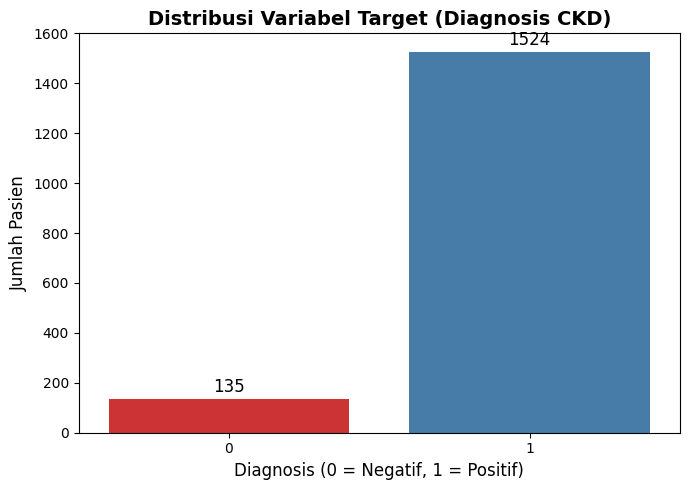

In [10]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_clean, x='Diagnosis', palette='Set1', order=[0, 1])
plt.title('Distribusi Variabel Target (Diagnosis CKD)', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis (0 = Negatif, 1 = Positif)', fontsize=12)
plt.ylabel('Jumlah Pasien', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black',
                xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

### 5.4 Distribusi Fitur Numerik — Histogram + KDE

Tiga fitur kami pilih sebagai representasi:
- **Age**: Demografis, distribusi simetris
- **BMI**: Antropometri, distribusi mendekati normal
- **SerumCreatinine**: Biokimia ginjal, distribusi menceng kanan

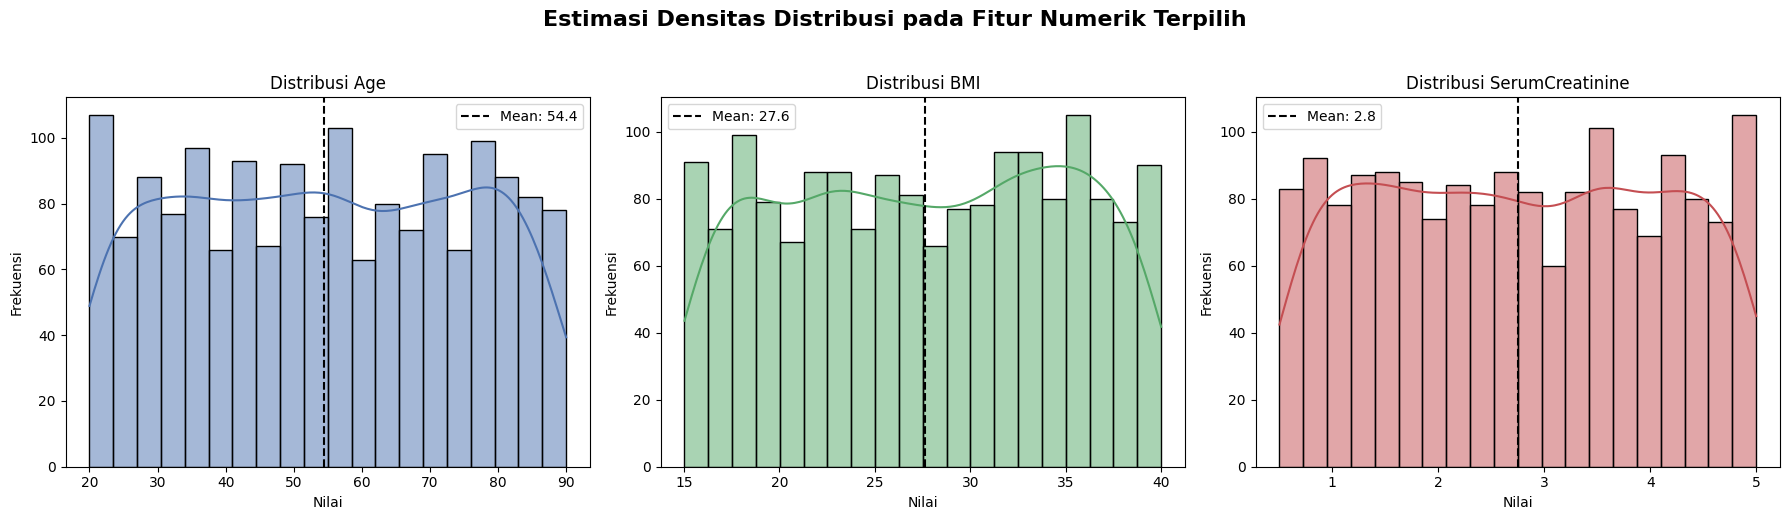

In [11]:
sample_features = ['Age', 'BMI', 'SerumCreatinine']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Estimasi Densitas Distribusi pada Fitur Numerik Terpilih',
             fontsize=16, fontweight='bold', y=1.03)

colors = ['#4C72B0', '#55A868', '#C44E52']
for i, col in enumerate(sample_features):
    sns.histplot(data=df_clean, x=col, kde=True, ax=axes[i],
                 color=colors[i], bins=20)
    axes[i].set_title(f'Distribusi {col}', fontsize=12)
    axes[i].set_ylabel('Frekuensi', fontsize=10)
    axes[i].set_xlabel('Nilai', fontsize=10)
    mean_val = df_clean[col].mean()
    axes[i].axvline(mean_val, color='black', linestyle='dashed',
                    linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()

### 5.5 Pair Plot — Fitur Utama berdasarkan Diagnosis

Visualisasi multivariat untuk melihat pola separasi antar kelas pada fitur-fitur kunci.

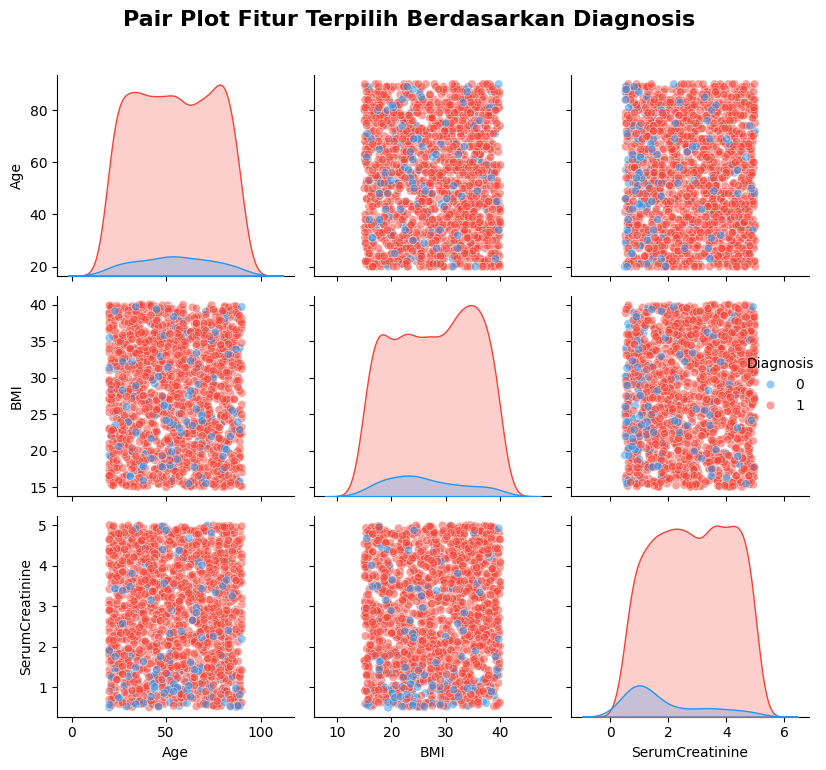

In [12]:
pairplot_cols = ['Age', 'BMI', 'SerumCreatinine', 'Diagnosis']

g = sns.pairplot(df_clean[pairplot_cols], hue='Diagnosis',
                 palette={0: '#2196F3', 1: '#F44336'},
                 diag_kind='kde', plot_kws={'alpha': 0.5})
g.fig.suptitle('Pair Plot Fitur Terpilih Berdasarkan Diagnosis',
               y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
print("Observasi:")
print("- Scatter plot SerumCreatinine vs fitur lain menunjukkan separasi kelas yang terlihat.")
print("- Pasien positif CKD (merah) cenderung memiliki SerumCreatinine lebih tinggi.")
print("- Age dan BMI menunjukkan overlap yang lebih besar antar kelas.")

Observasi:
- Scatter plot SerumCreatinine vs fitur lain menunjukkan separasi kelas yang terlihat.
- Pasien positif CKD (merah) cenderung memiliki SerumCreatinine lebih tinggi.
- Age dan BMI menunjukkan overlap yang lebih besar antar kelas.


## 6. Data Preprocessing

### 6.1 Penanganan Outlier — IQR Capping

**Metode:** IQR Capping (Winsorization)
- Nilai di bawah `Q1 - 1.5×IQR` -> Diganti dengan nilai batas bawah
- Nilai di atas `Q3 + 1.5×IQR` -> Diganti dengan nilai batas atas

**Alasan memilih Capping (bukan Drop):**  
Data medis mengandung nilai ekstrem yang valid secara klinis. Menghapus baris tersebut akan mengurangi ukuran dataset yang sudah kecil di kelas minoritas (135 pasien negatif). Capping mempertahankan semua observasi sambil meredam dampak nilai ekstrem terhadap model.

In [14]:
df_handled_outliers = df_clean.copy()

In [15]:
outlier_summary = []
for col in continuous_cols:
    Q1 = df_handled_outliers[col].quantile(0.25)
    Q3 = df_handled_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df_handled_outliers[col] < lower) | (df_handled_outliers[col] > upper)).sum()
    df_handled_outliers[col] = df_handled_outliers[col].clip(lower=lower, upper=upper)
    if n_outliers > 0:
        outlier_summary.append({'Fitur': col, 'Jumlah Outlier': n_outliers,
                                 'Lower Bound': round(lower, 3), 'Upper Bound': round(upper, 3)})

In [16]:
print(f"=== Outlier yang Ditangani ===")
df_outlier_summary = pd.DataFrame(outlier_summary).sort_values('Jumlah Outlier', ascending=False)
display(df_outlier_summary.reset_index(drop=True))
print(f"\nTotal fitur dengan outlier : {len(df_outlier_summary)}")
print("Semua outlier berhasil dicap tanpa menghapus baris data.")

=== Outlier yang Ditangani ===


,Fitur,Jumlah Outlier,Lower Bound,Upper Bound
0,Ethnicity,162,-1.5,2.5



Total fitur dengan outlier : 1
Semua outlier berhasil dicap tanpa menghapus baris data.


In [17]:
selected_for_boxplot = ['Age', 'BMI', 'SerumCreatinine']

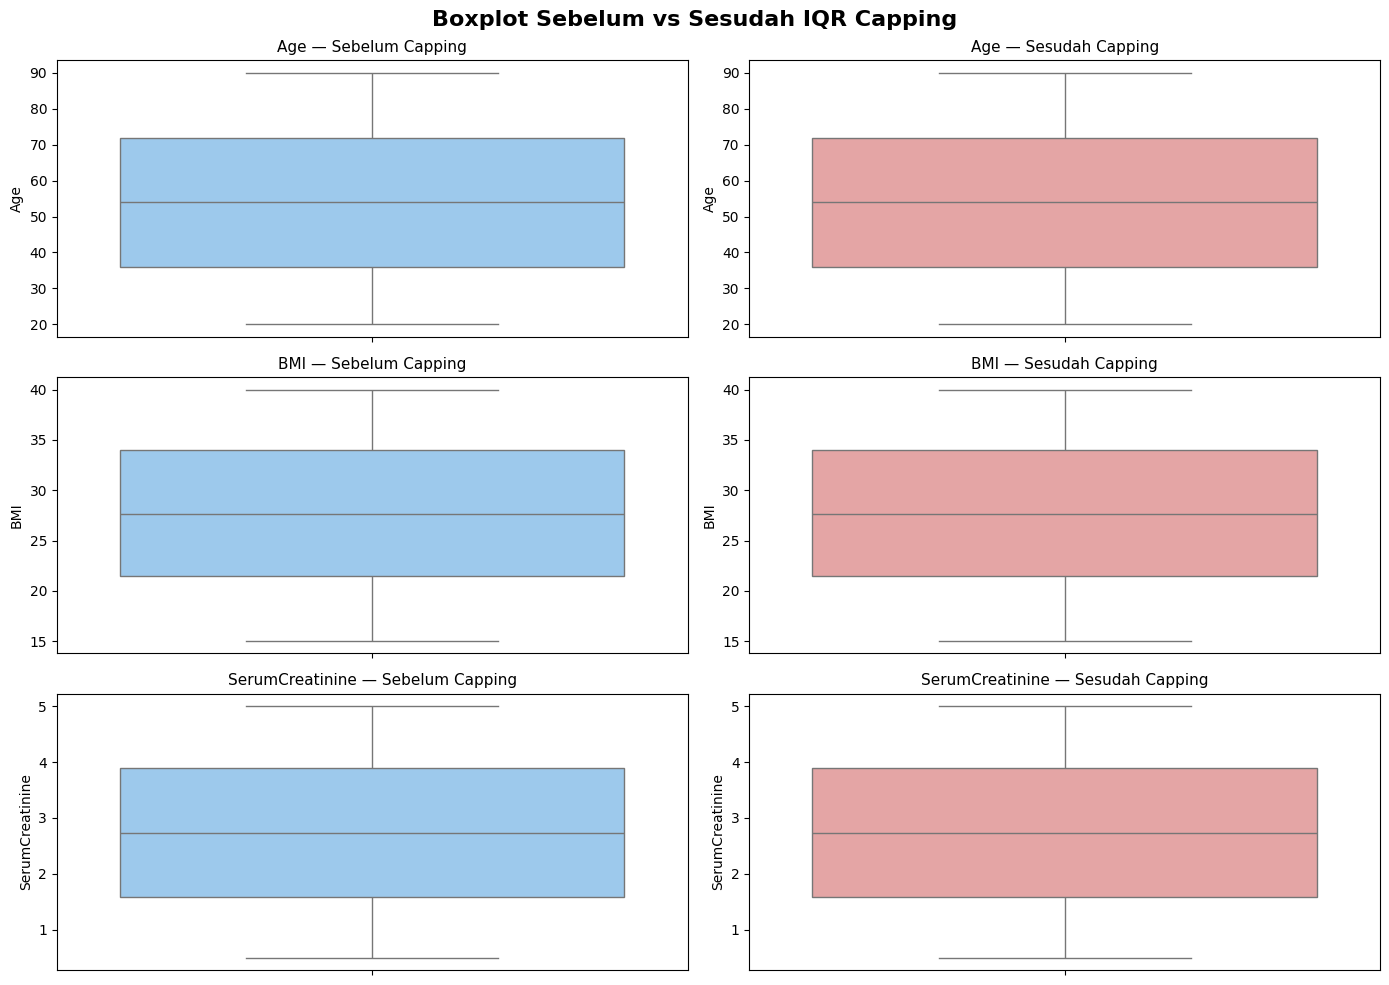

In [18]:
fig, axes = plt.subplots(len(selected_for_boxplot), 2, figsize=(14, 10))
fig.suptitle('Boxplot Sebelum vs Sesudah IQR Capping', fontsize=16, fontweight='bold')

for i, col in enumerate(selected_for_boxplot):
    sns.boxplot(y=df_clean[col], ax=axes[i, 0], color='#90CAF9')
    axes[i, 0].set_title(f'{col} — Sebelum Capping', fontsize=11)
    axes[i, 0].set_ylabel(col)

    sns.boxplot(y=df_handled_outliers[col], ax=axes[i, 1], color='#EF9A9A')
    axes[i, 1].set_title(f'{col} — Sesudah Capping', fontsize=11)
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.show()

In [19]:
print("=== Statistik Deskriptif: Sebelum Capping ===")
display(df_clean[selected_for_boxplot].describe().round(3))

=== Statistik Deskriptif: Sebelum Capping ===


,Age,BMI,SerumCreatinine
count,1659.000,1659.000,1659.000
mean,54.441,27.620,2.753
std,20.550,7.289,1.317
min,20.000,15.034,0.502
25%,36.000,21.471,1.583
50%,54.000,27.652,2.732
75%,72.000,34.016,3.890
max,90.000,39.994,4.999


In [20]:
print("\n=== Statistik Deskriptif: Sesudah Capping ===")
display(df_handled_outliers[selected_for_boxplot].describe().round(3))


=== Statistik Deskriptif: Sesudah Capping ===


,Age,BMI,SerumCreatinine
count,1659.000,1659.000,1659.000
mean,54.441,27.620,2.753
std,20.550,7.289,1.317
min,20.000,15.034,0.502
25%,36.000,21.471,1.583
50%,54.000,27.652,2.732
75%,72.000,34.016,3.890
max,90.000,39.994,4.999


### 6.2 Normalisasi Z-Score — StandardScaler

**Metode:** StandardScaler -> z = (x - μ) / σ

**Alasan:** Fitur kontinu memiliki skala yang sangat berbeda (Age dalam puluhan, ACR dalam ratusan, BUNLevels dalam puluhan). Perbedaan skala ini menyebabkan bias pada algoritma berbasis jarak (SVM, KNN) dan gradient descent. StandardScaler menormalisasi semua fitur kontinu ke mean ≈ 0 dan std ≈ 1.

**Input yang digunakan:** `df_handled_outliers` (data SETELAH outlier ditangani) — bukan `df_clean`.  
Ini memastikan normalisasi tidak terdistorsi oleh nilai ekstrem yang sudah di-cap.

**Fitur biner tidak dinormalisasi** karena sudah dalam skala 0–1 dan maknanya akan hilang jika ditransformasi.

In [21]:
print(f"Fitur yang akan dinormalisasi : {len(continuous_cols)} fitur kontinu")
print(f"Fitur yang dipertahankan      : {len(binary_cols)} fitur biner + 1 target (Diagnosis)")
print()

Fitur yang akan dinormalisasi : 36 fitur kontinu
Fitur yang dipertahankan      : 15 fitur biner + 1 target (Diagnosis)



In [22]:
scaler = StandardScaler()
df_processed = df_handled_outliers.copy()
df_processed[continuous_cols] = scaler.fit_transform(df_handled_outliers[continuous_cols])

In [23]:
sample_cols_norm = ['Age', 'BMI', 'SerumCreatinine']

print("=== Statistik SEBELUM Normalisasi (dari df_handled_outliers) ===")
display(df_handled_outliers[sample_cols_norm].describe().round(3).loc[['mean', 'std', 'min', 'max']])

print("\n=== Statistik SESUDAH Normalisasi (dari df_processed) ===")
display(df_processed[sample_cols_norm].describe().round(3).loc[['mean', 'std', 'min', 'max']])

print("\nInterpretasi:")
print("- Mean mendekati 0 dan Std mendekati 1 pada semua fitur -> normalisasi berhasil.")
print("- Fitur biner (Gender, Smoking, dll.) tidak berubah nilainya.")

=== Statistik SEBELUM Normalisasi (dari df_handled_outliers) ===


,Age,BMI,SerumCreatinine
mean,54.441,27.620,2.753
std,20.550,7.289,1.317
min,20.000,15.034,0.502
max,90.000,39.994,4.999



=== Statistik SESUDAH Normalisasi (dari df_processed) ===


,Age,BMI,SerumCreatinine
mean,-0.000,0.000,-0.000
std,1.000,1.000,1.000
min,-1.676,-1.727,-1.710
max,1.731,1.698,1.705



Interpretasi:
- Mean mendekati 0 dan Std mendekati 1 pada semua fitur -> normalisasi berhasil.
- Fitur biner (Gender, Smoking, dll.) tidak berubah nilainya.


In [24]:
print("=== Verifikasi Fitur Biner (harus tetap 0/1) ===")
display(df_processed[binary_cols[:5]].describe().round(3).loc[['mean', 'std', 'min', 'max']])

=== Verifikasi Fitur Biner (harus tetap 0/1) ===


,Gender,Smoking,FamilyHistoryKidneyDisease,FamilyHistoryHypertension,FamilyHistoryDiabetes
mean,0.515,0.293,0.141,0.301,0.257
std,0.500,0.455,0.348,0.459,0.437
min,0.000,0.000,0.000,0.000,0.000
max,1.000,1.000,1.000,1.000,1.000


## 7. Validasi Data Akhir & Simpan Output

In [25]:
print("=== RINGKASAN PIPELINE PREPROCESSING ===")
print(f"{'Step':<5} {'Proses':<40} {'Keterangan'}")
print("-" * 80)
print(f"{'1':<5} {'Load Data':<40} {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"{'2':<5} {'Drop PatientID & DoctorInCharge':<40} {df_clean.shape[1]} kolom tersisa")
print(f"{'3':<5} {'Cek Missing Value':<40} 0 missing → tidak ada imputasi")
print(f"{'4':<5} {'Klasifikasi Fitur':<40} {len(binary_cols)} biner | {len(continuous_cols)} kontinu")
print(f"{'5':<5} {'Outlier Capping (IQR)':<40} {len(df_outlier_summary)} fitur di-cap, 0 baris dihapus")
print(f"{'6':<5} {'Normalisasi StandardScaler':<40} {len(continuous_cols)} fitur kontinu dinormalisasi")
print(f"{'OUT':<5} {'df_processed':<40} {df_processed.shape[0]} baris x {df_processed.shape[1]} kolom")

=== RINGKASAN PIPELINE PREPROCESSING ===
Step  Proses                                   Keterangan
--------------------------------------------------------------------------------
1     Load Data                                1659 baris x 54 kolom
2     Drop PatientID & DoctorInCharge          52 kolom tersisa
3     Cek Missing Value                        0 missing → tidak ada imputasi
4     Klasifikasi Fitur                        15 biner | 36 kontinu
5     Outlier Capping (IQR)                    1 fitur di-cap, 0 baris dihapus
6     Normalisasi StandardScaler               36 fitur kontinu dinormalisasi
OUT   df_processed                             1659 baris x 52 kolom


In [26]:
print("=== STRUKTUR DATA AKHIR ===")
print(df_processed.info())

=== STRUKTUR DATA AKHIR ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 52 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            1659 non-null   float64
 1   Gender                         1659 non-null   int64  
 2   Ethnicity                      1659 non-null   float64
 3   SocioeconomicStatus            1659 non-null   float64
 4   EducationLevel                 1659 non-null   float64
 5   BMI                            1659 non-null   float64
 6   Smoking                        1659 non-null   int64  
 7   AlcoholConsumption             1659 non-null   float64
 8   PhysicalActivity               1659 non-null   float64
 9   DietQuality                    1659 non-null   float64
 10  SleepQuality                   1659 non-null   float64
 11  FamilyHistoryKidneyDisease     1659 non-null   int64  
 12  FamilyHistoryHyperte

In [27]:
print("5 baris pertama data final:")
display(df_processed.head())

5 baris pertama data final:


,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis
0,0.806032,0,-0.743139,-1.259185,0.337031,0.473393,1,-0.835206,-1.168429,-1.671310,...,0.490246,0.868676,0.947049,0,0,1,-0.860001,0.006629,1.629671,1
1,-0.995019,0,-0.743139,0.028724,1.435526,0.284372,1,1.490368,1.170279,0.514741,...,-0.653308,0.618802,-0.345163,0,0,0,1.685111,1.129795,0.695382,1
2,1.244125,1,0.375616,-1.259185,-0.761465,1.341496,1,0.329927,1.599476,-1.020525,...,1.205499,-1.010611,1.550806,0,1,1,-0.499811,0.932782,0.761882,1
3,-0.702956,0,1.494370,-1.259185,-0.761465,0.509112,0,1.043694,-1.610721,0.675720,...,-0.666063,0.702294,1.450425,0,0,0,1.074293,-0.580357,0.511889,1
4,-0.556925,0,0.375616,0.028724,0.337031,-0.534379,0,-0.349434,-1.481089,-0.673929,...,1.617107,-0.521515,-1.598618,0,0,1,-1.502570,-0.382800,-1.278362,1


In [28]:
output_file = 'CKD_Preprocessed_Ready.csv'
df_processed.to_csv(output_file, index=False)
print(f"Data final berhasil disimpan sebagai '{output_file}'")
print(f"Shape: {df_processed.shape[0]} baris x {df_processed.shape[1]} kolom")

Data final berhasil disimpan sebagai 'CKD_Preprocessed_Ready.csv'
Shape: 1659 baris x 52 kolom


# **PROJECT 2 — SELEKSI FITUR**
## KELOMPOK 7 · KAL TIF-D

| No | Nama | NIM |
|----|------|-----|
| 1 | Muhammad Fakhri Aldiansyah | 245150201111049 |
| 2 | Jason Manuel | 245150201111050 |
| 3 | Putri Griselda Sonandi | 245150207111036 |

**Dosen:** Dr. Candra Dewi, S.Kom., M.Sc.  
**Dataset:** Chronic Kidney Disease (CKD)

---
## Alur Notebook
8. Seleksi Fitur - SelectFromModel (Random Forest)  
   - 8.1 Import Library Tambahan
   - 8.2 Persiapan Data untuk Seleksi Fitur
   - 8.3 Pelatihan Random Forest & Ekstraksi Feature Importance
   - 8.4 Visualisasi Feature Importance Seluruh Fitur
   - 8.5 Tuning Threshold untuk Eksplorasi Berbagai Nilai
   - 8.6 Visualisasi Hasil Tuning Threshold
   - 8.7 Seleksi Fitur Final Threshold: mean
   - 8.8 Visualisasi Hasil Seleksi Final
   - 8.9 Dataset Final Pasca Seleksi Fitur

## 8. Seleksi Fitur — SelectFromModel (Random Forest)

### Latar Belakang Metode

a. SelectFromModel memilih fitur berdasarkan skor kepentingan feature importance yang dihasilkan oleh suatu estimator setelah pelatihan. Pada kelompok ini, estimator yang digunakan adalah Random Forest Classifier sebagai salah satu metode tree-based yang robust untuk seleksi fitur. Random Forest menghitung kepentingan fitur menggunakan Mean Decrease in Impurity (MDI) yaitu rata-rata penurunan impurity (Gini impurity) yang dikontribusikan oleh suatu fitur di seluruh pohon keputusan dalam forest. Fitur yang lebih sering digunakan untuk membagi node dan menghasilkan penurunan impurity lebih besar akan mendapat skor importance lebih tinggi.

b. Alasan pemilihan metode ini untuk dataset CKD:
1. Dataset CKD memiliki campuran 15 fitur kategorikal dan 36 fitur kontinu numerik.
2. Metode ini mampu menangkap hubungan non-linear antara fitur dan target, berbeda dengan metode Filter (chi2, F-test) yang hanya mengukur hubungan linear.
3. Random Forest robust terhadap sisa outlier pasca capping dan tidak memerlukan normalisasi (StandardScaler) sebagai prasyarat. Meskipun pada implementasi ini data df_processe yang sudah terstandarisasi tetap digunakan agar konsisten dengan pipeline sebelumnya.
4. Parameter class_weight='balanced' dapat digunakan untuk mengatasi class imbalance sebesar 11,3:1 yang teridentifikasi pada tahap EDA.

c. Kategori metode: Embedded (importance dihitung seiring proses training, bukan sebelum atau sesudah).

### 8.1 Import Library Tambahan

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import StratifiedKFold, cross_val_score

print("Library seleksi fitur berhasil diimport.")

Library seleksi fitur berhasil diimport.


### 8.2 Persiapan Data untuk Seleksi Fitur

Data yang digunakan adalah df_processed, hasil akhir pipeline preprocessing (setelah IQR Capping + StandardScaler). Variabel fitur (X) dan target (y) dipisahkan dan diverifikasi bahwa tidak ada nilai kosong yang tersisa.

In [30]:
X = df_processed.drop(columns=['Diagnosis'])
y = df_processed['Diagnosis']
feature_names = X.columns.tolist()

print(f"Shape X (fitur)  : {X.shape}")
print(f"Shape y (target) : {y.shape}")
print(f"Jumlah fitur     : {len(feature_names)}")
print(f"Distribusi target: Positif CKD = {y.sum()} | Negatif CKD = {(y==0).sum()}")
print(f"Rasio imbalance  : {y.sum()/(y==0).sum():.1f}:1")
print(f"Missing value    : {X.isnull().sum().sum()}")

Shape X (fitur)  : (1659, 51)
Shape y (target) : (1659,)
Jumlah fitur     : 51
Distribusi target: Positif CKD = 1524 | Negatif CKD = 135
Rasio imbalance  : 11.3:1
Missing value    : 0


### 8.3 Pelatihan Random Forest & Ekstraksi Feature Importance

Random Forest dilatih dengan konfigurasi:
- n_estimators=200 —> jumlah pohon yang cukup untuk estimasi importance yang stabil
- class_weight='balanced' —> menangani class imbalance 11,3:1 secara otomatis
- max_depth=10 —> membatasi kedalaman pohon untuk mengurangi overfitting
- random_state=42 —> memastikan reproducibility

In [31]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X, y)

importances = rf_model.feature_importances_
std_importances = np.std(
    [tree.feature_importances_ for tree in rf_model.estimators_], axis=0
)

mean_importance   = importances.mean()
median_importance = np.median(importances)

df_importance = pd.DataFrame({
    'Fitur'     : feature_names,
    'Importance': importances,
    'Std'       : std_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=== TOP 20 FITUR BERDASARKAN RANDOM FOREST IMPORTANCE ===")
display(df_importance.head(20).round(5))


=== TOP 20 FITUR BERDASARKAN RANDOM FOREST IMPORTANCE ===


,Fitur,Importance,Std
0,SerumCreatinine,0.11110,0.06641
1,GFR,0.08308,0.04912
2,ProteinInUrine,0.05422,0.03683
3,Itching,0.04416,0.03077
4,FastingBloodSugar,0.03815,0.03049
5,MuscleCramps,0.03643,0.02874
6,BUNLevels,0.03520,0.02813
7,SystolicBP,0.02859,0.02554
8,CholesterolHDL,0.02692,0.02320
9,BMI,0.02568,0.02306


### 8.4 Visualisasi Feature Importance Seluruh Fitur

Grafik berikut menampilkan skor feature importance seluruh 51 fitur prediktif beserta error bar yang merepresentasikan standar deviasi kepentingan fitur antar 200 pohon. Error bar kecil berarti estimasi importance stabil dan konsisten.

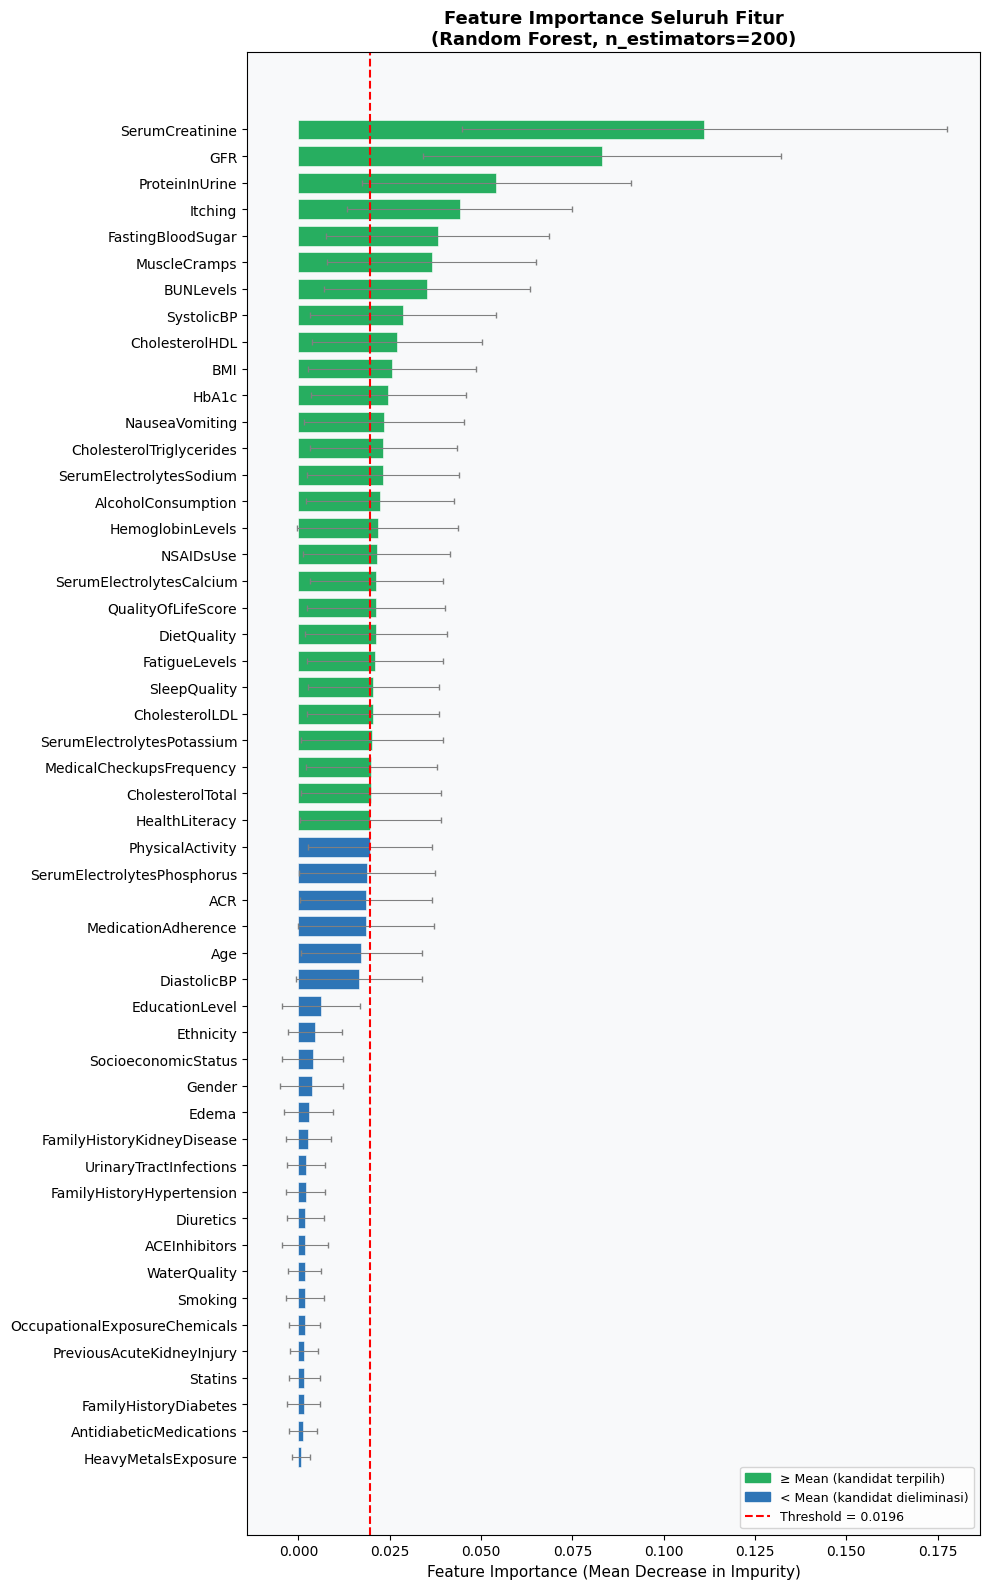

Mean importance (threshold default) : 0.01961
Fitur dengan importance >= mean      : 27
Fitur dengan importance <  mean      : 24


In [32]:
fig, ax = plt.subplots(figsize=(10, 16))

colors_imp = ['#27AE60' if imp > importances.mean() else '#2E75B6'
              for imp in df_importance['Importance']]

ax.barh(
    df_importance['Fitur'][::-1],
    df_importance['Importance'][::-1],
    xerr=df_importance['Std'][::-1],
    color=colors_imp[::-1],
    error_kw={'ecolor': 'gray', 'capsize': 2, 'linewidth': 0.8},
    edgecolor='white', linewidth=0.4, height=0.75
)

mean_importance = importances.mean()
ax.axvline(x=mean_importance, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean Importance = {mean_importance:.4f} (threshold default)')

ax.set_title('Feature Importance Seluruh Fitur\n(Random Forest, n_estimators=200)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_facecolor('#F8F9FA')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#27AE60', label=f'≥ Mean (kandidat terpilih)'),
    Patch(color='#2E75B6', label=f'< Mean (kandidat dieliminasi)'),
    plt.Line2D([0],[0], color='red', linestyle='--', label=f'Threshold = {mean_importance:.4f}')
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

print(f"Mean importance (threshold default) : {mean_importance:.5f}")
print(f"Fitur dengan importance >= mean      : {(importances >= mean_importance).sum()}")
print(f"Fitur dengan importance <  mean      : {(importances < mean_importance).sum()}")

### 8.5 Tuning Threshold untuk Eksplorasi Berbagai Nilai

Perlu melakukan tuning/thresholding untuk mengamati bagaimana jumlah fitur terpilih berubah pada kondisi threshold yang berbeda. SelectFromModel mendukung beberapa jenis threshold:

| Threshold | Interpretasi |
|-----------|-------------|
| `'mean'` | Pilih fitur dengan importance ≥ rata-rata semua fitur |
| `'median'` | Pilih fitur dengan importance ≥ median semua fitur |
| `'0.5*mean'` | Threshold lebih longgar (50% dari mean) → lebih banyak fitur terpilih |
| `'2*mean'` | Threshold lebih ketat (200% dari mean) → lebih sedikit fitur terpilih |
| Custom (numerik) | Nilai threshold eksplisit, misalnya 0.01, 0.015, 0.02 |

In [33]:
thresholds_config = [
    ('0.5*mean',     mean_importance * 0.5),
    ('mean',         mean_importance),
    ('median',       median_importance),
    ('1.5*mean',     mean_importance * 1.5),
    ('2*mean',       mean_importance * 2.0),
    ('0.005 (custom)', 0.005),
    ('0.010 (custom)', 0.010),
    ('0.015 (custom)', 0.015),
    ('0.020 (custom)', 0.020),
    ('0.025 (custom)', 0.025),
    ('0.030 (custom)', 0.030),
]

threshold_results = []
for label, thr_val in thresholds_config:
    n_selected   = int((importances >= thr_val).sum())
    n_eliminated = int((importances < thr_val).sum())
    threshold_results.append({
        'Threshold'        : label,
        'Nilai Threshold'  : round(thr_val, 5),
        'Fitur Terpilih'   : n_selected,
        'Fitur Dieliminasi': n_eliminated
    })

df_tuning = pd.DataFrame(threshold_results)
print("=== HASIL TUNING THRESHOLD ===")
display(df_tuning)


=== HASIL TUNING THRESHOLD ===


,Threshold,Nilai Threshold,Fitur Terpilih,Fitur Dieliminasi
0,0.5*mean,0.00980,33,18
1,mean,0.01961,27,24
2,median,0.01983,26,25
3,1.5*mean,0.02941,7,44
4,2*mean,0.03922,4,47
5,0.005 (custom),0.00500,34,17
6,0.010 (custom),0.01000,33,18
7,0.015 (custom),0.01500,33,18
8,0.020 (custom),0.02000,24,27
9,0.025 (custom),0.02500,10,41


**Interpretasi hasil tuning:**

Tabel di atas menunjukkan sensitivitas seleksi fitur terhadap nilai threshold. Threshold mean merupakan titik keseimbangan yang umum digunakan karena memilih fitur yang berkontribusi di atas rata-rata secara intuitif, hal ini berarti hanya fitur yang lebih penting dari rata-rata yang dipertahankan. Threshold yang terlalu rendah (misalnya 0.5 * mean) akan mempertahankan terlalu banyak fitur dan berisiko membawa noise ke model, sementara threshold yang terlalu tinggi (misalnya 2 * mean) sangat agresif dan mungkin membuang fitur yang masih relevan. Pada dataset CKD ini, threshold mean dipilih sebagai konfigurasi final karena menghasilkan jumlah fitur yang reasonable sambil mempertahankan fitur-fitur dengan importance konsisten di atas rata-rata.

### 8.6 Visualisasi Hasil Tuning Threshold

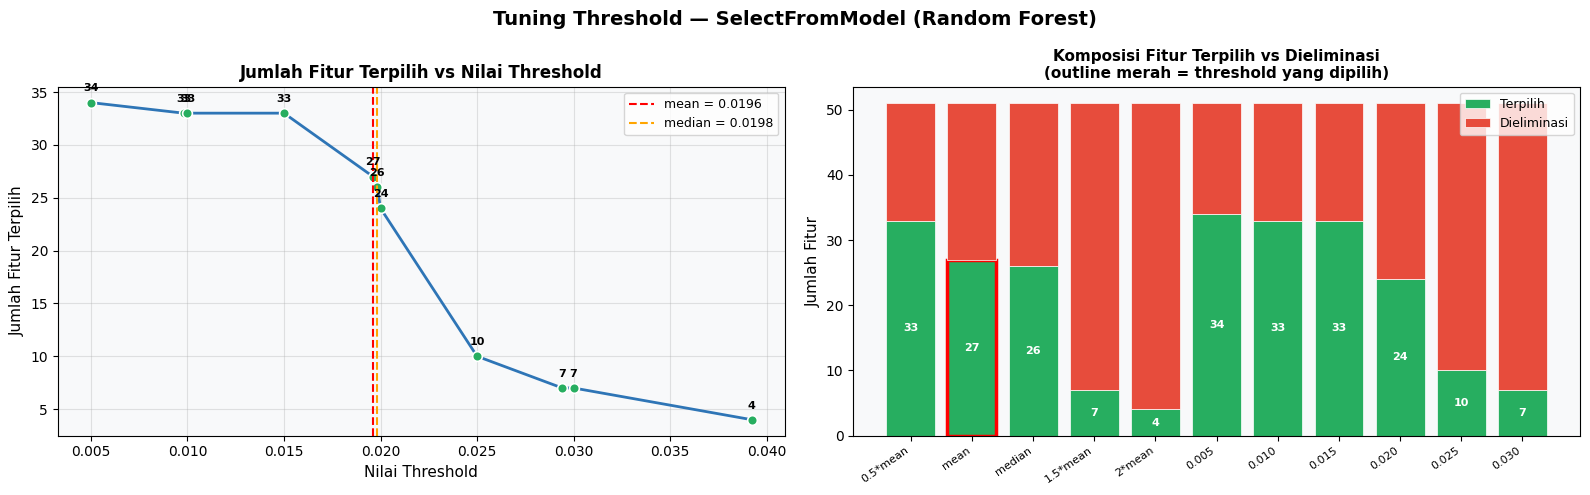

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Tuning Threshold — SelectFromModel (Random Forest)',
             fontsize=14, fontweight='bold')

# Plot 1: Jumlah fitur terpilih vs nilai threshold (semua)
df_plot_all = df_tuning.sort_values('Nilai Threshold')

axes[0].plot(df_plot_all['Nilai Threshold'], df_plot_all['Fitur Terpilih'],
             'o-', color='#2E75B6', linewidth=2, markersize=7,
             markerfacecolor='#27AE60', markeredgecolor='white', markeredgewidth=1.2)

# Threshold mean dan median
mean_row   = df_tuning[df_tuning['Threshold'] == 'mean'].iloc[0]
median_row = df_tuning[df_tuning['Threshold'] == 'median'].iloc[0]

axes[0].axvline(x=mean_row['Nilai Threshold'], color='red',
                linestyle='--', linewidth=1.5, label=f"mean = {mean_row['Nilai Threshold']:.4f}")
axes[0].axvline(x=median_row['Nilai Threshold'], color='orange',
                linestyle='--', linewidth=1.5, label=f"median = {median_row['Nilai Threshold']:.4f}")

for _, row in df_plot_all.iterrows():
    axes[0].annotate(f"{int(row['Fitur Terpilih'])}",
                     (row['Nilai Threshold'], row['Fitur Terpilih']),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=8, fontweight='bold')

axes[0].set_xlabel('Nilai Threshold', fontsize=11)
axes[0].set_ylabel('Jumlah Fitur Terpilih', fontsize=11)
axes[0].set_title('Jumlah Fitur Terpilih vs Nilai Threshold', fontsize=12, fontweight='bold')
axes[0].set_facecolor('#F8F9FA')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.35)

# Plot 2: Stacked bar terpilih vs dieliminasi
df_bar = df_tuning.copy()
x_pos = range(len(df_bar))
labels = df_bar['Threshold'].str.replace(' (custom)', '', regex=False)

axes[1].bar(x_pos, df_bar['Fitur Terpilih'], color='#27AE60',
            label='Terpilih', edgecolor='white', linewidth=0.5)
axes[1].bar(x_pos, df_bar['Fitur Dieliminasi'], bottom=df_bar['Fitur Terpilih'],
            color='#E74C3C', label='Dieliminasi', edgecolor='white', linewidth=0.5)

for i, (sel, eli) in enumerate(zip(df_bar['Fitur Terpilih'], df_bar['Fitur Dieliminasi'])):
    axes[1].text(i, sel/2, str(sel), ha='center', va='center',
                 fontsize=8, fontweight='bold', color='white')

# Highlight kolom mean
mean_idx = df_bar[df_bar['Threshold'] == 'mean'].index[0]
axes[1].get_children()[mean_idx].set_edgecolor('red')
axes[1].get_children()[mean_idx].set_linewidth(2.5)

axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
axes[1].set_ylabel('Jumlah Fitur', fontsize=11)
axes[1].set_title('Komposisi Fitur Terpilih vs Dieliminasi\n(outline merah = threshold yang dipilih)',
                  fontsize=11, fontweight='bold')
axes[1].set_facecolor('#F8F9FA')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 8.7 Seleksi Fitur Final — Threshold: mean

Berdasarkan hasil eksplorasi tuning, threshold mean dipilih sebagai konfigurasi final. Threshold ini secara otomatis dihitung sebagai rata-rata feature importance dari seluruh fitur sehingga bersifat adaptif terhadap distribusi importance yang dihasilkan model.

In [35]:
# SelectFromModel dengan threshold final = mean
selector_final = SelectFromModel(
    RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=10, random_state=42, n_jobs=-1
    ),
    threshold='mean'
)
selector_final.fit(X, y)

X_selected    = selector_final.transform(X)
mask_final    = selector_final.get_support()
threshold_final = selector_final.threshold_

selected_features = [f for f, m in zip(feature_names, mask_final) if m]
dropped_features  = [f for f, m in zip(feature_names, mask_final) if not m]

print("=" * 60)
print(f"SELEKSI FITUR FINAL (threshold = 'mean' = {threshold_final:.5f})")
print("=" * 60)
print(f"  Fitur sebelum seleksi : {len(feature_names)}")
print(f"  Fitur terpilih        : {len(selected_features)}")
print(f"  Fitur dieliminasi     : {len(dropped_features)}")
print()
print("  FITUR TERPILIH:")
for i, f in enumerate(selected_features, 1):
    imp = selector_final.estimator_.feature_importances_[feature_names.index(f)]
    print(f"    {i:2d}. {f:<35} (importance = {imp:.5f})")
print()
print("  FITUR DIELIMINASI (importance < threshold):")
dropped_sorted = sorted(
    dropped_features,
    key=lambda f: selector_final.estimator_.feature_importances_[feature_names.index(f)],
    reverse=True
)
for i, f in enumerate(dropped_sorted, 1):
    imp = selector_final.estimator_.feature_importances_[feature_names.index(f)]
    print(f"    {i:2d}. {f:<35} (importance = {imp:.5f})")


SELEKSI FITUR FINAL (threshold = 'mean' = 0.01961)
  Fitur sebelum seleksi : 51
  Fitur terpilih        : 27
  Fitur dieliminasi     : 24

  FITUR TERPILIH:
     1. BMI                                 (importance = 0.02568)
     2. AlcoholConsumption                  (importance = 0.02223)
     3. DietQuality                         (importance = 0.02116)
     4. SleepQuality                        (importance = 0.02053)
     5. SystolicBP                          (importance = 0.02859)
     6. FastingBloodSugar                   (importance = 0.03815)
     7. HbA1c                               (importance = 0.02461)
     8. SerumCreatinine                     (importance = 0.11110)
     9. BUNLevels                           (importance = 0.03520)
    10. GFR                                 (importance = 0.08308)
    11. ProteinInUrine                      (importance = 0.05422)
    12. SerumElectrolytesSodium             (importance = 0.02322)
    13. SerumElectrolytesPotassium     

### 8.8 Visualisasi Hasil Seleksi Final

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

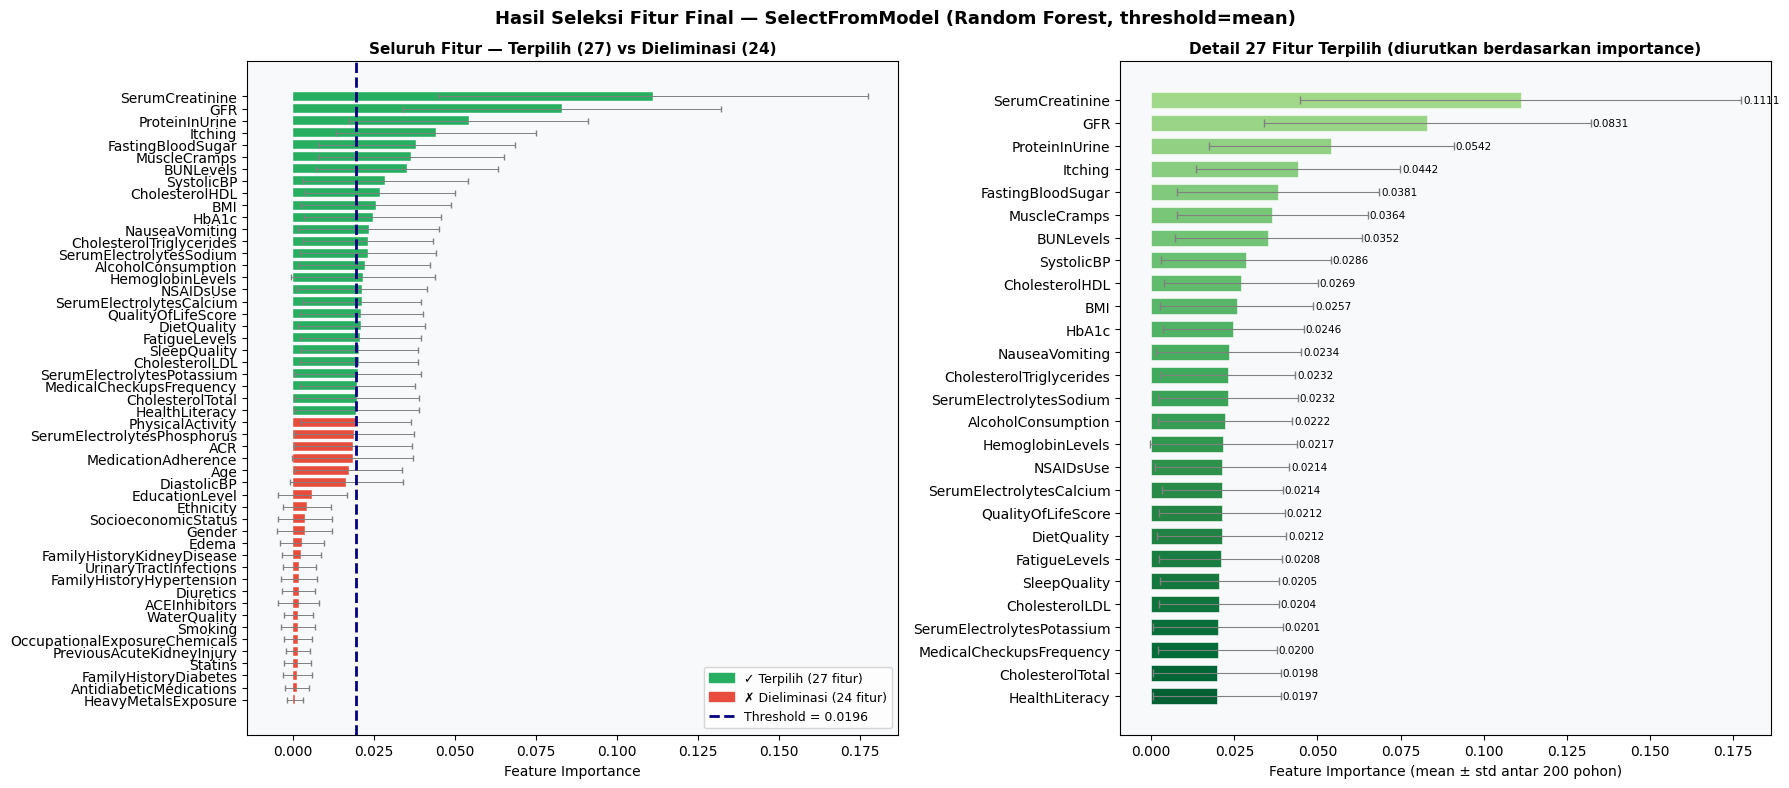

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Hasil Seleksi Fitur Final — SelectFromModel (Random Forest, threshold=mean)',
             fontsize=13, fontweight='bold')

# Plot 1: Semua fitur, highlight terpilih, garis threshold
df_final_plot = df_importance.copy()
df_final_plot['Selected'] = df_final_plot['Fitur'].isin(selected_features)
bar_colors = ['#27AE60' if s else '#E74C3C' for s in df_final_plot['Selected']]

axes[0].barh(
    df_final_plot['Fitur'][::-1],
    df_final_plot['Importance'][::-1],
    xerr=df_final_plot['Std'][::-1],
    color=bar_colors[::-1],
    error_kw={'ecolor': 'gray', 'capsize': 2, 'linewidth': 0.7},
    edgecolor='white', linewidth=0.3, height=0.75
)
axes[0].axvline(x=threshold_final, color='navy', linestyle='--', linewidth=2,
                label=f'Threshold (mean) = {threshold_final:.4f}')
axes[0].set_title(f'Seluruh Fitur — Terpilih ({len(selected_features)}) vs Dieliminasi ({len(dropped_features)})',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Feature Importance', fontsize=10)
axes[0].set_facecolor('#F8F9FA')

from matplotlib.patches import Patch
import matplotlib.lines as mlines
axes[0].legend(handles=[
    Patch(color='#27AE60', label=f'✓ Terpilih ({len(selected_features)} fitur)'),
    Patch(color='#E74C3C', label=f'✗ Dieliminasi ({len(dropped_features)} fitur)'),
    mlines.Line2D([],[],color='navy',linestyle='--',linewidth=2,
                  label=f'Threshold = {threshold_final:.4f}')
], fontsize=9)

# Plot 2: Importance fitur terpilih + error bar (detail)
df_sel_plot = df_importance[df_importance['Fitur'].isin(selected_features)].copy()
df_sel_plot = df_sel_plot.sort_values('Importance', ascending=False).reset_index(drop=True)

cmap_sel = plt.cm.YlGn(np.linspace(0.4, 0.9, len(df_sel_plot)))[::-1]
axes[1].barh(
    df_sel_plot['Fitur'][::-1],
    df_sel_plot['Importance'][::-1],
    xerr=df_sel_plot['Std'][::-1],
    color=cmap_sel,
    error_kw={'ecolor': 'gray', 'capsize': 3, 'linewidth': 0.8},
    edgecolor='white', linewidth=0.4, height=0.7
)
for i, (_, row) in enumerate(df_sel_plot[::-1].iterrows()):
    axes[1].text(row['Importance'] + row['Std'] + 0.0005,
                 i, f"{row['Importance']:.4f}", va='center', fontsize=7.5)

axes[1].set_title(f'Detail {len(selected_features)} Fitur Terpilih (diurutkan berdasarkan importance)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Feature Importance (mean ± std antar 200 pohon)', fontsize=10)
axes[1].set_facecolor('#F8F9FA')

plt.tight_layout()
plt

### 8.9 Dataset Final Pasca Seleksi Fitur

Dataset final yang akan digunakan untuk tahap klasifikasi merupakan subset dari df_processed yang hanya memuat fitur-fitur terpilih beserta variabel target Diagnosis.

In [37]:
df_final_selected = df_processed[selected_features + ['Diagnosis']].copy()

print("=== RINGKASAN PIPELINE SELEKSI FITUR ===")
print(f"{'Step':<5} {'Proses':<45} {'Keterangan'}")
print("-" * 85)
print(f"{'IN':<5} {'Input (df_processed)':<45} {df_processed.shape[0]} baris x {df_processed.shape[1]} kolom")
print(f"{'1':<5} {'Latih RandomForestClassifier':<45} n_estimators=200, class_weight=balanced")
print(f"{'2':<5} {'Hitung Feature Importance (MDI)':<45} {len(feature_names)} fitur dievaluasi")
print(f"{'3':<5} {'Eksplorasi Threshold (tuning)':<45} {len(df_tuning)} kondisi threshold diuji")
print(f"{'4':<5} {'Seleksi Final (threshold=mean)':<45} threshold = {threshold_final:.5f}")
print(f"{'OUT':<5} {'df_final_selected':<45} {df_final_selected.shape[0]} baris x {df_final_selected.shape[1]} kolom")
print()
print(f"Reduksi dimensi: {len(feature_names)} → {len(selected_features)} fitur "
      f"({len(dropped_features)} fitur dieliminasi, "
      f"{len(selected_features)/len(feature_names)*100:.1f}% fitur dipertahankan)")
print()
print("=== STRUKTUR DATASET FINAL ===")
print(df_final_selected.info())

=== RINGKASAN PIPELINE SELEKSI FITUR ===
Step  Proses                                        Keterangan
-------------------------------------------------------------------------------------
IN    Input (df_processed)                          1659 baris x 52 kolom
1     Latih RandomForestClassifier                  n_estimators=200, class_weight=balanced
2     Hitung Feature Importance (MDI)               51 fitur dievaluasi
3     Eksplorasi Threshold (tuning)                 11 kondisi threshold diuji
4     Seleksi Final (threshold=mean)                threshold = 0.01961
OUT   df_final_selected                             1659 baris x 28 kolom

Reduksi dimensi: 51 → 27 fitur (24 fitur dieliminasi, 52.9% fitur dipertahankan)

=== STRUKTUR DATASET FINAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   BMI    

In [38]:
print("5 baris pertama dataset final (fitur terpilih + Diagnosis):")
display(df_final_selected.head())

5 baris pertama dataset final (fitur terpilih + Diagnosis):


,BMI,AlcoholConsumption,DietQuality,SleepQuality,SystolicBP,FastingBloodSugar,HbA1c,SerumCreatinine,BUNLevels,GFR,...,CholesterolTriglycerides,NSAIDsUse,FatigueLevels,NauseaVomiting,MuscleCramps,Itching,QualityOfLifeScore,MedicalCheckupsFrequency,HealthLiteracy,Diagnosis
0,0.473393,-0.835206,-1.671310,-1.682210,-0.830450,-1.642006,1.285161,1.677841,-0.154027,-0.703221,...,-0.126724,-0.156356,-0.501756,1.767706,0.490246,0.868676,0.947049,-0.860001,1.629671,1
1,0.284372,1.490368,0.514741,0.417040,-0.558711,-0.866725,-1.371644,0.306508,0.293655,-0.367645,...,0.305576,1.423967,0.107286,-1.574176,-0.653308,0.618802,-0.345163,1.685111,0.695382,1
2,1.341496,0.329927,-1.020525,-1.496519,0.489425,0.778617,-0.894413,0.717693,0.949690,0.024294,...,0.270192,-0.404492,-0.055700,0.600268,1.205499,-1.010611,1.550806,-0.499811,0.761882,1
3,0.509112,1.043694,0.675720,-0.387434,-0.675170,1.531439,-1.637199,0.087540,-0.437137,-1.119330,...,1.670469,1.000384,1.213975,1.112626,-0.666063,0.702294,1.450425,1.074293,0.511889,1
4,-0.534379,-0.349434,-0.673929,-1.714374,-1.412747,-1.378111,-1.568860,0.920190,-1.199745,-0.349850,...,1.452957,-0.290091,-1.241393,-0.608685,1.617107,-0.521515,-1.598618,-1.502570,-1.278362,1


In [39]:
output_selected = 'CKD_Feature_Selected.csv'
df_final_selected.to_csv(output_selected, index=False)
print(f"Dataset final berhasil disimpan sebagai '{output_selected}'")
print(f"Shape: {df_final_selected.shape[0]} baris x {df_final_selected.shape[1]} kolom")
print(f"Fitur terpilih: {selected_features}")

Dataset final berhasil disimpan sebagai 'CKD_Feature_Selected.csv'
Shape: 1659 baris x 28 kolom
Fitur terpilih: ['BMI', 'AlcoholConsumption', 'DietQuality', 'SleepQuality', 'SystolicBP', 'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR', 'ProteinInUrine', 'SerumElectrolytesSodium', 'SerumElectrolytesPotassium', 'SerumElectrolytesCalcium', 'HemoglobinLevels', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'NSAIDsUse', 'FatigueLevels', 'NauseaVomiting', 'MuscleCramps', 'Itching', 'QualityOfLifeScore', 'MedicalCheckupsFrequency', 'HealthLiteracy']


# **PROJECT 3 — KLASIFIKASI**
## KELOMPOK 7 · KAL TIF-D

| No | Nama | NIM |
|----|------|-----|
| 1 | Muhammad Fakhri Aldiansyah | 245150201111049 |
| 2 | Jason Manuel | 245150201111050 |
| 3 | Putri Griselda Sonandi | 245150207111036 |

**Dosen:** Dr. Candra Dewi, S.Kom., M.Sc.  
**Dataset:** Chronic Kidney Disease (CKD)  
**Algoritma:** HistGradientBoostingClassifier (`sklearn.ensemble`)

---
## Alur Project 3
9. Klasifikasi Histogram Gradient Boosting
   - 9.1 Import Library
   - 9.2 Reproduksi Pipeline Project 1 & 2
   - 9.3 Persiapan Data & Analisis Class Imbalance
   - 9.4 Solusi: sample_weight + Threshold Tuning
   - 9.5 Manual SMOTE
   - 9.6 Baseline Model (Tanpa Penanganan Imbalance)
   - 9.7 Tuning Hyperparameter (di atas data dengan sample_weight)
   - 9.8 Model Final — Training dengan sample_weight
   - 9.9 Threshold Tuning via F1-macro Sweep
   - 9.10 Evaluasi Model — Cross-Validation (5-Fold)
   - 9.11 Evaluasi Model — Test Set
   - 9.12 Perbandingan Baseline vs Revisi
   - 9.13 Kurva ROC & Precision-Recall
   - 9.14 Feature Importance (Permutation)
   - 9.15 9.15 Visualisasi: Validation Curve (Overfitting / Underfitting)
   - 9.16 Ringkasan

## 9.1 Import Library Tambahan

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score, accuracy_score
)
from sklearn.inspection import permutation_importance
from sklearn.neighbors import NearestNeighbors

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


## 9.2 Reproduksi Pipeline Project 1 & 2

In [41]:
# PROJECT 1: Load & Cleaning
df = pd.read_csv('CKD.csv', sep=';')
COLS_TO_DROP = ['PatientID', 'DoctorInCharge']
df_clean = df.drop(columns=COLS_TO_DROP)

binary_cols = [
    col for col in df_clean.columns
    if col != 'Diagnosis' and df_clean[col].nunique() == 2
]
continuous_cols = [
    col for col in df_clean.columns
    if col not in binary_cols and col != 'Diagnosis'
]

# IQR Capping
df_handled = df_clean.copy()
for col in continuous_cols:
    Q1, Q3 = df_handled[col].quantile(0.25), df_handled[col].quantile(0.75)
    IQR = Q3 - Q1
    df_handled[col] = df_handled[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# StandardScaler
scaler = StandardScaler()
df_processed = df_handled.copy()
df_processed[continuous_cols] = scaler.fit_transform(df_handled[continuous_cols])

print(f"Shape setelah preprocessing : {df_processed.shape}")

# PROJECT 2: Feature Selection (SelectFromModel RF)
X_all = df_processed.drop('Diagnosis', axis=1)
y_all = df_processed['Diagnosis']

rf_sel = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_sel.fit(X_all, y_all)
selector = SelectFromModel(rf_sel, threshold='mean', prefit=True)

X_selected = pd.DataFrame(
    selector.transform(X_all),
    columns=X_all.columns[selector.get_support()]
)
selected_features = X_selected.columns.tolist()

print(f"Fitur terpilih (threshold=mean) : {len(selected_features)} fitur")
print(f"Fitur: {selected_features}")

Shape setelah preprocessing : (1659, 52)
Fitur terpilih (threshold=mean) : 27 fitur
Fitur: ['BMI', 'AlcoholConsumption', 'DietQuality', 'SystolicBP', 'DiastolicBP', 'FastingBloodSugar', 'HbA1c', 'SerumCreatinine', 'BUNLevels', 'GFR', 'ProteinInUrine', 'SerumElectrolytesSodium', 'SerumElectrolytesPotassium', 'SerumElectrolytesPhosphorus', 'HemoglobinLevels', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'NSAIDsUse', 'FatigueLevels', 'NauseaVomiting', 'MuscleCramps', 'Itching', 'QualityOfLifeScore', 'MedicationAdherence', 'HealthLiteracy']


## 9.3 Persiapan Data & Analisis Class Imbalance

> **Inti masalah:** Dataset CKD memiliki distribusi kelas yang sangat timpang (*heavily imbalanced*).
> Kelas mayoritas (Positif CKD) mendominasi ~91.9% data, sedangkan kelas minoritas (Negatif CKD)
> hanya ~8.1%. Rasio ketimpangan mencapai **11,3:1**.

=== DISTRIBUSI KELAS ===
Kelas                        Train     Test    Total
--------------------------------------------------
0 — Negatif CKD                108       27      135
1 — Positif CKD               1219      305     1524

Rasio imbalance (pos:neg) : 11.3:1

Implikasi:
Model naif yang selalu prediksi Positif CKD → Accuracy = 91.9%
Recall Negatif CKD = 0%  ← inilah yang terjadi pada baseline


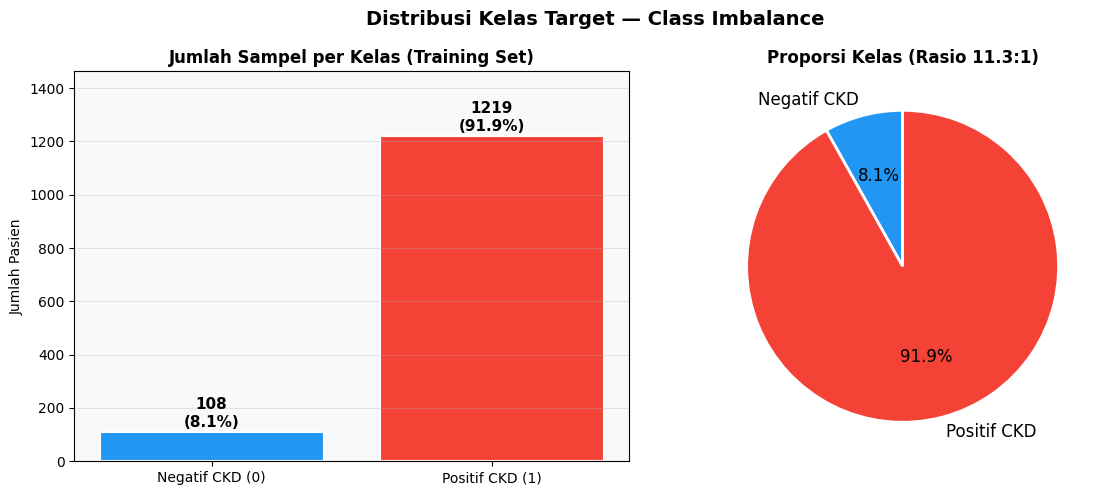

In [42]:
# Train/Test Split (stratified)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y_all,
    test_size=0.2, stratify=y_all, random_state=42
)

neg_train = (y_tr == 0).sum()
pos_train = (y_tr == 1).sum()
imbalance_ratio = pos_train / neg_train

print("=== DISTRIBUSI KELAS ===")
print(f"{'Kelas':<25} {'Train':>8} {'Test':>8} {'Total':>8}")
print("-" * 50)
print(f"{'0 — Negatif CKD':<25} {neg_train:>8} {(y_te==0).sum():>8} {(y_all==0).sum():>8}")
print(f"{'1 — Positif CKD':<25} {pos_train:>8} {(y_te==1).sum():>8} {(y_all==1).sum():>8}")
print(f"\nRasio imbalance (pos:neg) : {imbalance_ratio:.1f}:1")
print()
print("Implikasi:")
print(f"Model naif yang selalu prediksi Positif CKD → Accuracy = {pos_train/(pos_train+neg_train)*100:.1f}%")
print(f"Recall Negatif CKD = 0%  ← inilah yang terjadi pada baseline")

# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Kelas Target — Class Imbalance', fontsize=14, fontweight='bold')

# Bar chart
colors = ['#2196F3', '#F44336']
counts = [neg_train, pos_train]
bars = axes[0].bar(['Negatif CKD (0)', 'Positif CKD (1)'], counts, color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{count}\n({count/(neg_train+pos_train)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Jumlah Sampel per Kelas (Training Set)', fontweight='bold')
axes[0].set_ylabel('Jumlah Pasien')
axes[0].set_facecolor('#F8F9FA')
axes[0].set_ylim(0, pos_train * 1.2)
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
axes[1].pie([neg_train, pos_train], labels=['Negatif CKD', 'Positif CKD'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title(f'Proporsi Kelas (Rasio {imbalance_ratio:.1f}:1)', fontweight='bold')

plt.tight_layout()
plt.show()

## 9.4 Solusi: sample_weight + Threshold Tuning

### Mengapa sample_weight lebih efektif dari SMOTE untuk kasus ini?

| Aspek | SMOTE | `sample_weight` |
|-------|-------|-----------------|
| Cara kerja | Buat sampel sintetis baru dengan interpolasi | Beri bobot loss lebih besar pada kelas minoritas |
| Cocok untuk | Minority class ≥ 50-100 sampel, cluster padat | Semua kondisi imbalance, langsung dari model |
| Risiko | Noise jika minoritas terlalu kecil atau tidak padat | Minimal, tidak mengubah distribusi data |
| Kompatibel dengan HistGradBoost | Perlu preprocessing | Native parameter sample_weight |

### Threshold Tuning
Default threshold predict() = **0.5** artinya: prediksi Positif CKD jika P(CKD=1) ≥ 0.5.  
Dengan data imbalanced, model belajar bahwa probabilitas aman untuk Positif CKD sudah >0.5 hampir selalu.  
**Threshold diturunkan** → model lebih agresif mendeteksi Negatif CKD → recall kelas 0 naik.

## 9.5 Manual SMOTE

In [43]:
def smote_minority(X, y, minority_class=0, k=5, target_ratio=1.0, random_state=42):
    """
    SMOTE (Synthetic Minority Over-sampling Technique) — implementasi manual.

    Parameter:
    ----------
    X             : array fitur (numpy array)
    y             : array label (numpy array)
    minority_class: nilai kelas yang akan di-oversample (default: 0)
    k             : jumlah tetangga terdekat untuk interpolasi (default: 5)
    target_ratio  : rasio akhir minority/majority (1.0 = seimbang, 0.5 = 1:2)
    random_state  : seed untuk reproducibility

    Returns:
    --------
    X_resampled, y_resampled
    """
    np.random.seed(random_state)
    X = np.array(X, dtype=float)
    y = np.array(y)

    minority_idx   = np.where(y == minority_class)[0]
    majority_count = (y != minority_class).sum()
    minority_count = len(minority_idx)

    target_minority = int(majority_count * target_ratio / (1 + target_ratio))
    n_synthetic     = max(0, target_minority - minority_count)

    if n_synthetic == 0:
        return X, y

    X_min = X[minority_idx]
    nn = NearestNeighbors(n_neighbors=min(k + 1, len(X_min)))
    nn.fit(X_min)
    _, indices = nn.kneighbors(X_min)

    synthetic = []
    for _ in range(n_synthetic):
        i          = np.random.randint(0, len(X_min))
        nn_choice  = np.random.choice(indices[i][1:])
        gap        = np.random.random()
        new_sample = X_min[i] + gap * (X_min[nn_choice] - X_min[i])
        synthetic.append(new_sample)

    X_new = np.vstack([X, np.array(synthetic)])
    y_new = np.hstack([y, np.full(n_synthetic, minority_class)])
    return X_new, y_new


print("Fungsi smote_minority berhasil didefinisikan.")
print(f"  - Input training: {neg_train} Negatif CKD | {pos_train} Positif CKD")

# Demo SMOTE untuk ilustrasi distribusi setelah oversampling
X_smote_demo, y_smote_demo = smote_minority(
    X_tr.values, y_tr.values, minority_class=0, k=5, target_ratio=0.5, random_state=42
)
print(f"  - Setelah SMOTE (ratio=0.5): "
      f"{(y_smote_demo==0).sum()} Negatif | {(y_smote_demo==1).sum()} Positif")
print("  - (SMOTE digunakan hanya pada training set, TIDAK pada test set)")

Fungsi smote_minority berhasil didefinisikan.
  - Input training: 108 Negatif CKD | 1219 Positif CKD
  - Setelah SMOTE (ratio=0.5): 406 Negatif | 1219 Positif
  - (SMOTE digunakan hanya pada training set, TIDAK pada test set)


## 9.6 Baseline Model (Tanpa Penanganan Imbalance)

In [44]:
# Baseline: HistGradBoost tanpa sample_weight, threshold=0.5
clf_base = HistGradientBoostingClassifier(random_state=42)
clf_base.fit(X_tr, y_tr)
y_pred_base  = clf_base.predict(X_te)
y_prob_base  = clf_base.predict_proba(X_te)[:, 1]

print("=== BASELINE MODEL — Classification Report ===")
print(classification_report(y_te, y_pred_base,
      target_names=['Negatif CKD (0)', 'Positif CKD (1)'], digits=4))
print(f"ROC-AUC  : {roc_auc_score(y_te, y_prob_base):.4f}")
print(f"F1-macro : {f1_score(y_te, y_pred_base, average='macro'):.4f}")
print()
cm_b = confusion_matrix(y_te, y_pred_base)
tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
print(f"Confusion Matrix: TN={tn_b}  FP={fp_b}  FN={fn_b}  TP={tp_b}")
print(f"Recall Negatif CKD: {tn_b/(tn_b+fp_b):.4f}  ← SANGAT RENDAH (masalah utama)")
print(f"Recall Positif CKD: {tp_b/(tp_b+fn_b):.4f}")

=== BASELINE MODEL — Classification Report ===
                 precision    recall  f1-score   support

Negatif CKD (0)     0.6667    0.2222    0.3333        27
Positif CKD (1)     0.9350    0.9902    0.9618       305

       accuracy                         0.9277       332
      macro avg     0.8008    0.6062    0.6476       332
   weighted avg     0.9132    0.9277    0.9107       332

ROC-AUC  : 0.8174
F1-macro : 0.6476

Confusion Matrix: TN=6  FP=21  FN=3  TP=302
Recall Negatif CKD: 0.2222  ← SANGAT RENDAH (masalah utama)
Recall Positif CKD: 0.9902


## 9.7 Tuning Hyperparameter (di atas data dengan sample_weight)

Tuning dilakukan di atas data training (sebelum sample_weight)
dengan Stratified 5-Fold CV menggunakan ROC-AUC dan F1-macro sebagai metrik panduan.

In [45]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Tuning learning_rate
lr_values = [0.01, 0.05, 0.1, 0.2, 0.3]
lr_aucs, lr_f1s = [], []

for lr in lr_values:
    clf = HistGradientBoostingClassifier(learning_rate=lr, max_iter=100, random_state=42)
    a   = cross_val_score(clf, X_selected, y_all, cv=cv_strat, scoring='roc_auc').mean()
    f   = cross_val_score(clf, X_selected, y_all, cv=cv_strat, scoring='f1_macro').mean()
    lr_aucs.append(a); lr_f1s.append(f)
    print(f"learning_rate={lr:.2f}  AUC={a:.4f}  F1-macro={f:.4f}")

best_lr = lr_values[np.argmax(lr_aucs)]
print(f"\n→ Best learning_rate : {best_lr}  (AUC={max(lr_aucs):.4f})")

learning_rate=0.01  AUC=0.7933  F1-macro=0.5260
learning_rate=0.05  AUC=0.8163  F1-macro=0.6666
learning_rate=0.10  AUC=0.8159  F1-macro=0.6578
learning_rate=0.20  AUC=0.8240  F1-macro=0.6403
learning_rate=0.30  AUC=0.8233  F1-macro=0.6628

→ Best learning_rate : 0.2  (AUC=0.8240)


In [46]:
# Tuning max_iter
iter_values = [50, 100, 200, 300, 500]
iter_aucs, iter_f1s = [], []

for n in iter_values:
    clf = HistGradientBoostingClassifier(learning_rate=best_lr, max_iter=n, random_state=42)
    a   = cross_val_score(clf, X_selected, y_all, cv=cv_strat, scoring='roc_auc').mean()
    f   = cross_val_score(clf, X_selected, y_all, cv=cv_strat, scoring='f1_macro').mean()
    iter_aucs.append(a); iter_f1s.append(f)
    print(f"max_iter={n:<5}  AUC={a:.4f}  F1-macro={f:.4f}")

best_iter = iter_values[np.argmax(iter_aucs)]
print(f"\n→ Best max_iter : {best_iter}  (AUC={max(iter_aucs):.4f})")

max_iter=50     AUC=0.8213  F1-macro=0.6455
max_iter=100    AUC=0.8240  F1-macro=0.6403
max_iter=200    AUC=0.8257  F1-macro=0.6449
max_iter=300    AUC=0.8270  F1-macro=0.6608
max_iter=500    AUC=0.8288  F1-macro=0.6550

→ Best max_iter : 500  (AUC=0.8288)


In [47]:
# Tuning max_depth
depth_values = [None, 3, 4, 5, 6, 8]
depth_labels = ['None', '3', '4', '5', '6', '8']
depth_aucs, depth_f1s = [], []

for d in depth_values:
    clf = HistGradientBoostingClassifier(learning_rate=best_lr, max_iter=best_iter,
                                          max_depth=d, random_state=42)
    a   = cross_val_score(clf, X_selected, y_all, cv=cv_strat, scoring='roc_auc').mean()
    f   = cross_val_score(clf, X_selected, y_all, cv=cv_strat, scoring='f1_macro').mean()
    depth_aucs.append(a); depth_f1s.append(f)
    print(f"max_depth={str(d):<5}  AUC={a:.4f}  F1-macro={f:.4f}")

best_depth = depth_values[np.argmax(depth_aucs)]
print(f"\n→ Best max_depth : {best_depth}  (AUC={max(depth_aucs):.4f})")

max_depth=None   AUC=0.8288  F1-macro=0.6550
max_depth=3      AUC=0.8003  F1-macro=0.6528
max_depth=4      AUC=0.8213  F1-macro=0.6591
max_depth=5      AUC=0.8237  F1-macro=0.6522
max_depth=6      AUC=0.8194  F1-macro=0.6632
max_depth=8      AUC=0.8199  F1-macro=0.6553

→ Best max_depth : None  (AUC=0.8288)


In [48]:
# Tuning l2_regularization
l2_values = [0.0, 0.01, 0.1, 0.5, 1.0]
l2_aucs, l2_f1s = [], []

for l2 in l2_values:
    clf = HistGradientBoostingClassifier(learning_rate=best_lr, max_iter=best_iter,
                                          max_depth=best_depth, l2_regularization=l2,
                                          random_state=42)
    a   = cross_val_score(clf, X_selected, y_all, cv=cv_strat, scoring='roc_auc').mean()
    f   = cross_val_score(clf, X_selected, y_all, cv=cv_strat, scoring='f1_macro').mean()
    l2_aucs.append(a); l2_f1s.append(f)
    print(f"l2_reg={l2:<5}  AUC={a:.4f}  F1-macro={f:.4f}")

best_l2 = l2_values[np.argmax(l2_aucs)]
print(f"\n→ Best l2_regularization : {best_l2}  (AUC={max(l2_aucs):.4f})")
print(f"\n=== KONFIGURASI TERBAIK ===")
print(f"learning_rate     : {best_lr}")
print(f"max_iter          : {best_iter}")
print(f"max_depth         : {best_depth}")
print(f"l2_regularization : {best_l2}")

l2_reg=0.0    AUC=0.8288  F1-macro=0.6550
l2_reg=0.01   AUC=0.8227  F1-macro=0.6626
l2_reg=0.1    AUC=0.8258  F1-macro=0.6446
l2_reg=0.5    AUC=0.8275  F1-macro=0.6650
l2_reg=1.0    AUC=0.8249  F1-macro=0.6528

→ Best l2_regularization : 0.0  (AUC=0.8288)

=== KONFIGURASI TERBAIK ===
learning_rate     : 0.2
max_iter          : 500
max_depth         : None
l2_regularization : 0.0


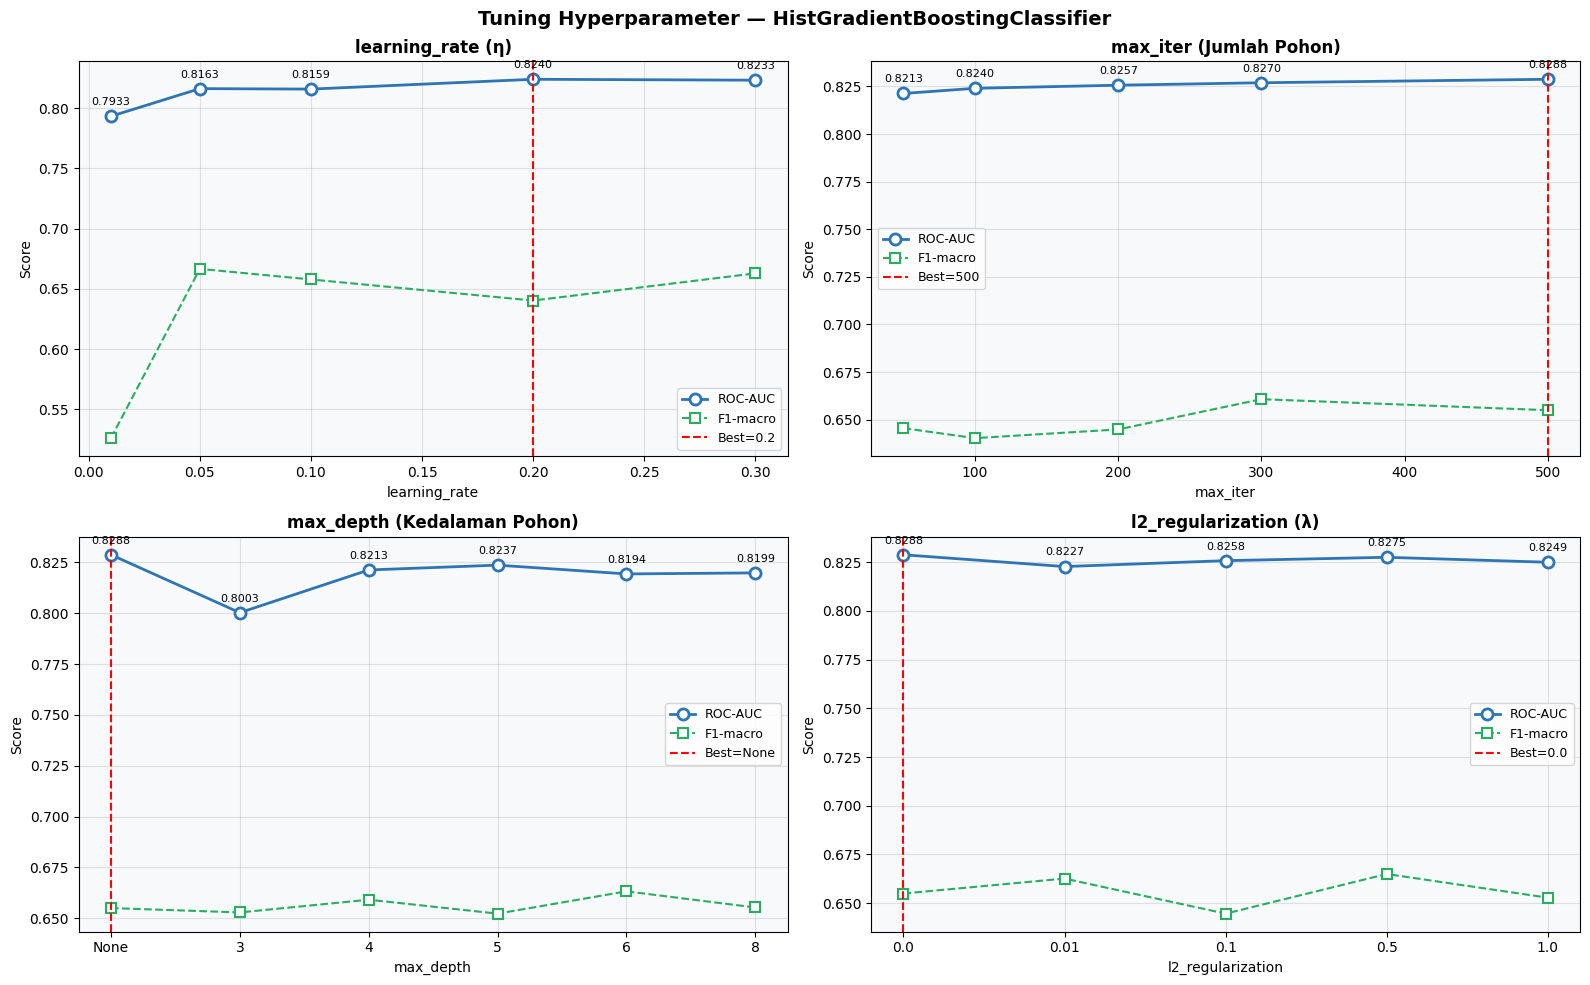

In [49]:
# Visualisasi Tuning
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Tuning Hyperparameter — HistGradientBoostingClassifier',
             fontsize=14, fontweight='bold')
BLUE, GREEN = '#2E75B6', '#27AE60'

def plot_tuning(ax, x_vals, aucs, f1s, best_val, title, xlabel, x_labels=None):
    xs = list(range(len(x_vals))) if x_labels else x_vals
    ax.plot(xs, aucs, 'o-', color=BLUE, lw=2, ms=8, label='ROC-AUC',
            markerfacecolor='white', markeredgewidth=2)
    ax.plot(xs, f1s, 's--', color=GREEN, lw=1.5, ms=7, label='F1-macro',
            markerfacecolor='white', markeredgewidth=1.5)
    best_x = xs[x_vals.index(best_val)] if x_labels else best_val
    ax.axvline(best_x, color='red', ls='--', lw=1.5, label=f'Best={best_val}')
    for x, y in zip(xs, aucs):
        ax.annotate(f'{y:.4f}', (x, y), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)
    if x_labels:
        ax.set_xticks(xs); ax.set_xticklabels(x_labels)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel); ax.set_ylabel('Score')
    ax.legend(fontsize=9); ax.set_facecolor('#F8F9FA')
    ax.grid(True, alpha=0.35)

plot_tuning(axes[0,0], lr_values, lr_aucs, lr_f1s, best_lr, 'learning_rate (η)', 'learning_rate')
plot_tuning(axes[0,1], iter_values, iter_aucs, iter_f1s, best_iter, 'max_iter (Jumlah Pohon)', 'max_iter')
plot_tuning(axes[1,0], depth_values, depth_aucs, depth_f1s, best_depth,
            'max_depth (Kedalaman Pohon)', 'max_depth', depth_labels)
plot_tuning(axes[1,1], l2_values, l2_aucs, l2_f1s, best_l2,
            'l2_regularization (λ)', 'l2_regularization', [str(v) for v in l2_values])

plt.tight_layout()
plt.show()

## 9.8 Model Final — Training dengan sample_weight

sample_weight memberikan bobot proporsional terhadap rasio ketimpangan kelas.
Setiap sampel kelas minoritas (Negatif CKD) diberi bobot = rasio (pos/neg) ≈ 11.3,
sehingga loss function memberikan penalti lebih besar saat model salah mengklasifikasi kelas ini.

In [50]:
# sample_weight berdasarkan rasio imbalance
neg_count_tr = (y_tr == 0).sum()
pos_count_tr = (y_tr == 1).sum()
class_ratio   = pos_count_tr / neg_count_tr

# Bobot: kelas minoritas mendapat bobot = class_ratio; kelas mayoritas = 1.0
sample_weights = np.where(y_tr == 0, class_ratio, 1.0)

print("=== KONFIGURASI sample_weight ===")
print(f"Neg CKD (kelas 0) : {neg_count_tr} sampel → bobot per sampel = {class_ratio:.2f}")
print(f"Pos CKD (kelas 1) : {pos_count_tr} sampel → bobot per sampel = 1.00")
print(f"Efektif loss neg  : {neg_count_tr * class_ratio:.0f}  (setara jumlah Positif CKD)")
print(f"Efektif loss pos  : {pos_count_tr * 1.0:.0f}")
print()

# Model Final
clf_final = HistGradientBoostingClassifier(
    learning_rate     = best_lr,
    max_iter          = best_iter,
    max_depth         = best_depth,
    l2_regularization = best_l2,
    random_state      = 42
)
clf_final.fit(X_tr, y_tr, sample_weight=sample_weights)

print(f"Model berhasil dilatih pada {len(X_tr)} sampel dengan sample_weight.")
print(f"Hyperparameter: lr={best_lr}, iter={best_iter}, depth={best_depth}, l2={best_l2}")

=== KONFIGURASI sample_weight ===
Neg CKD (kelas 0) : 108 sampel → bobot per sampel = 11.29
Pos CKD (kelas 1) : 1219 sampel → bobot per sampel = 1.00
Efektif loss neg  : 1219  (setara jumlah Positif CKD)
Efektif loss pos  : 1219

Model berhasil dilatih pada 1327 sampel dengan sample_weight.
Hyperparameter: lr=0.2, iter=500, depth=None, l2=0.0


## 9.9 Threshold Tuning via F1-macro Sweep

Default threshold 0.5 masih bias mayoritas. Sweep dilakukan di rentang [0.05, 0.95]
dengan langkah 0.01, memilih threshold yang memaksimalkan **F1-macro** (rata-rata F1 antar kelas).

Default threshold (0.50) → F1-macro = 0.6371
Optimal threshold (0.93)  → F1-macro = 0.6856  ← dipilih


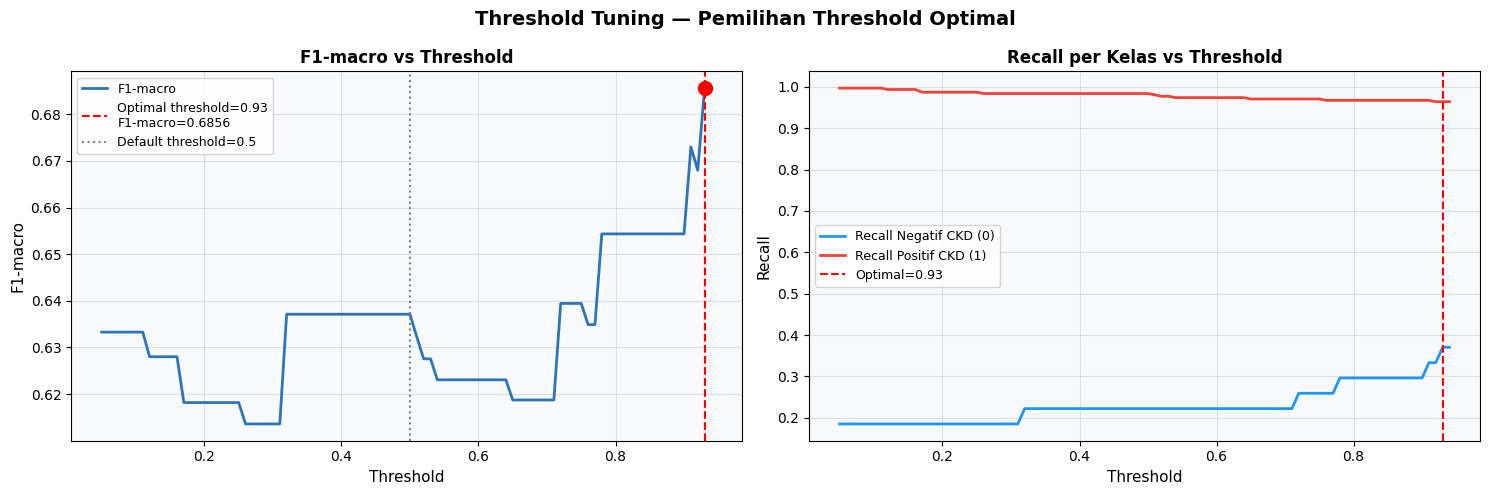


Threshold 0.93 dipilih karena memaksimalkan keseimbangan
recall antar kelas (F1-macro optimal).


In [51]:
y_prob_final = clf_final.predict_proba(X_te)[:, 1]

# Threshold sweep pada test set
threshold_range = np.arange(0.05, 0.95, 0.01)
f1_macro_scores = []
neg_recalls, pos_recalls = [], []

for t in threshold_range:
    y_pred_t = (y_prob_final >= t).astype(int)
    if len(np.unique(y_pred_t)) < 2:
        f1_macro_scores.append(0)
        neg_recalls.append(0); pos_recalls.append(0)
        continue
    f1_macro_scores.append(f1_score(y_te, y_pred_t, average='macro', zero_division=0))
    cm_t = confusion_matrix(y_te, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    neg_recalls.append(tn_t / (tn_t + fp_t) if (tn_t+fp_t)>0 else 0)
    pos_recalls.append(tp_t / (tp_t + fn_t) if (tp_t+fn_t)>0 else 0)

best_idx    = np.argmax(f1_macro_scores)
best_thresh = threshold_range[best_idx]
best_f1m    = f1_macro_scores[best_idx]

print(f"Default threshold (0.50) → F1-macro = {f1_score(y_te, (y_prob_final>=0.5).astype(int), average='macro'):.4f}")
print(f"Optimal threshold ({best_thresh:.2f})  → F1-macro = {best_f1m:.4f}  ← dipilih")

# Visualisasi Threshold Sweep
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Threshold Tuning — Pemilihan Threshold Optimal', fontsize=14, fontweight='bold')

# Plot 1: F1-macro vs threshold
axes[0].plot(threshold_range, f1_macro_scores, color='#2E75B6', lw=2, label='F1-macro')
axes[0].axvline(best_thresh, color='red', ls='--', lw=1.5,
                label=f'Optimal threshold={best_thresh:.2f}\nF1-macro={best_f1m:.4f}')
axes[0].axvline(0.5, color='gray', ls=':', lw=1.5, label='Default threshold=0.5')
axes[0].scatter(best_thresh, best_f1m, color='red', s=100, zorder=5)
axes[0].set_xlabel('Threshold', fontsize=11)
axes[0].set_ylabel('F1-macro', fontsize=11)
axes[0].set_title('F1-macro vs Threshold', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].set_facecolor('#F8F9FA')
axes[0].grid(True, alpha=0.35)

# Plot 2: Recall per kelas vs threshold
axes[1].plot(threshold_range, neg_recalls, color='#2196F3', lw=2, label='Recall Negatif CKD (0)')
axes[1].plot(threshold_range, pos_recalls, color='#F44336', lw=2, label='Recall Positif CKD (1)')
axes[1].axvline(best_thresh, color='red', ls='--', lw=1.5, label=f'Optimal={best_thresh:.2f}')
axes[1].set_xlabel('Threshold', fontsize=11)
axes[1].set_ylabel('Recall', fontsize=11)
axes[1].set_title('Recall per Kelas vs Threshold', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].set_facecolor('#F8F9FA')
axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

print(f"\nThreshold {best_thresh:.2f} dipilih karena memaksimalkan keseimbangan")
print(f"recall antar kelas (F1-macro optimal).")

## 9.10 Evaluasi Model — Cross-Validation (5-Fold)

> SMOTE dan threshold tuning diterapkan di **dalam** setiap fold
> untuk mencegah data leakage. Threshold dioptimalkan per fold menggunakan data validasi fold tersebut.


In [52]:
cv_strat5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_arr = X_selected.values
y_arr = y_all.values

cv_auc, cv_f1m, cv_f1w, cv_acc, cv_prec, cv_rec = [], [], [], [], [], []
cv_neg_recall, cv_pos_recall, cv_thresh = [], [], []

print("=== 5-FOLD STRATIFIED CV (sample_weight + threshold tuning per fold) ===")
print(f"{'Fold':<6} {'ROC-AUC':>9} {'F1-macro':>9} {'F1-weighted':>12} {'Accuracy':>10} "
      f"{'Rec-Neg':>9} {'Rec-Pos':>9} {'Threshold':>10}")
print("─" * 80)

for fold, (tr_idx, val_idx) in enumerate(cv_strat5.split(X_arr, y_arr)):
    X_f_tr, y_f_tr = X_arr[tr_idx], y_arr[tr_idx]
    X_f_val, y_f_val = X_arr[val_idx], y_arr[val_idx]

    # sample_weight per fold
    ratio_f = (y_f_tr == 1).sum() / (y_f_tr == 0).sum()
    sw_f    = np.where(y_f_tr == 0, ratio_f, 1.0)

    clf_f = HistGradientBoostingClassifier(
        learning_rate=best_lr, max_iter=best_iter,
        max_depth=best_depth, l2_regularization=best_l2, random_state=42)
    clf_f.fit(X_f_tr, y_f_tr, sample_weight=sw_f)

    y_prob_f = clf_f.predict_proba(X_f_val)[:, 1]

    # Threshold sweep per fold
    best_f1_f, best_t_f = 0, 0.5
    for t in np.arange(0.05, 0.95, 0.02):
        y_pred_tmp = (y_prob_f >= t).astype(int)
        if len(np.unique(y_pred_tmp)) < 2: continue
        f1_tmp = f1_score(y_f_val, y_pred_tmp, average='macro', zero_division=0)
        if f1_tmp > best_f1_f:
            best_f1_f, best_t_f = f1_tmp, t

    y_pred_f = (y_prob_f >= best_t_f).astype(int)
    cm_f = confusion_matrix(y_f_val, y_pred_f)
    tn_f, fp_f, fn_f, tp_f = cm_f.ravel()

    auc_s  = roc_auc_score(y_f_val, y_prob_f)
    f1m_s  = f1_score(y_f_val, y_pred_f, average='macro')
    f1w_s  = f1_score(y_f_val, y_pred_f, average='weighted')
    acc_s  = accuracy_score(y_f_val, y_pred_f)
    prec_s = precision_score(y_f_val, y_pred_f, average='macro', zero_division=0)
    rec_s  = recall_score(y_f_val, y_pred_f, average='macro')
    neg_r  = tn_f / (tn_f + fp_f) if (tn_f+fp_f)>0 else 0
    pos_r  = tp_f / (tp_f + fn_f) if (tp_f+fn_f)>0 else 0

    cv_auc.append(auc_s); cv_f1m.append(f1m_s); cv_f1w.append(f1w_s)
    cv_acc.append(acc_s); cv_prec.append(prec_s); cv_rec.append(rec_s)
    cv_neg_recall.append(neg_r); cv_pos_recall.append(pos_r); cv_thresh.append(best_t_f)

    print(f"Fold {fold+1:<1}  {auc_s:>9.4f} {f1m_s:>9.4f} {f1w_s:>12.4f} "
          f"{acc_s:>10.4f} {neg_r:>9.4f} {pos_r:>9.4f} {best_t_f:>10.2f}")

print("─" * 80)
print(f"{'Mean':<6}  {np.mean(cv_auc):>9.4f} {np.mean(cv_f1m):>9.4f} {np.mean(cv_f1w):>12.4f} "
      f"{np.mean(cv_acc):>10.4f} {np.mean(cv_neg_recall):>9.4f} {np.mean(cv_pos_recall):>9.4f}")
print(f"{'Std':<6}  {np.std(cv_auc):>9.4f} {np.std(cv_f1m):>9.4f} {np.std(cv_f1w):>12.4f} "
      f"{np.std(cv_acc):>10.4f} {np.std(cv_neg_recall):>9.4f} {np.std(cv_pos_recall):>9.4f}")

=== 5-FOLD STRATIFIED CV (sample_weight + threshold tuning per fold) ===
Fold     ROC-AUC  F1-macro  F1-weighted   Accuracy   Rec-Neg   Rec-Pos  Threshold
────────────────────────────────────────────────────────────────────────────────
Fold 1     0.8563    0.7754       0.9363     0.9398    0.5185    0.9770       0.91
Fold 2     0.8459    0.7281       0.9304     0.9428    0.3333    0.9967       0.65
Fold 3     0.8146    0.7074       0.9229     0.9337    0.3333    0.9869       0.83
Fold 4     0.7559    0.7074       0.9229     0.9337    0.3333    0.9869       0.87
Fold 5     0.8576    0.8203       0.9489     0.9517    0.5926    0.9836       0.93
────────────────────────────────────────────────────────────────────────────────
Mean       0.8261    0.7477       0.9323     0.9403    0.4222    0.9862
Std        0.0384    0.0440       0.0097     0.0067    0.1114    0.0064


## 9.11 Evaluasi Model — Test Set



=== CLASSIFICATION REPORT — TEST SET (Threshold Optimal) ===
                 precision    recall  f1-score   support

Negatif CKD (0)     0.4762    0.3704    0.4167        27
Positif CKD (1)     0.9453    0.9639    0.9545       305

       accuracy                         0.9157       332
      macro avg     0.7108    0.6672    0.6856       332
   weighted avg     0.9072    0.9157    0.9108       332

ROC-AUC Score    : 0.7951
Avg Precision    : 0.9707
Threshold dipakai: 0.93


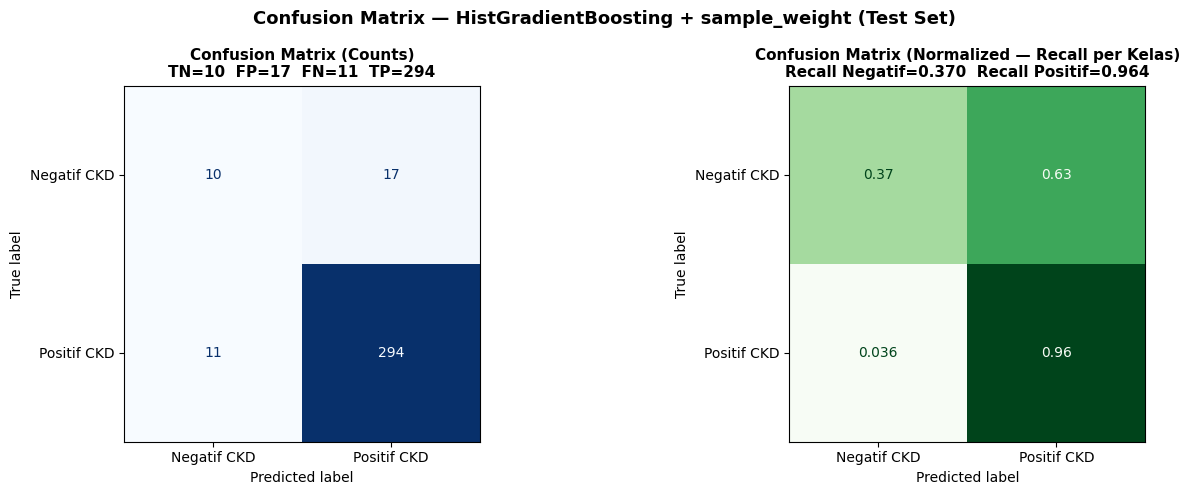


Interpretasi:
True Positive  (TP): 294  — Positif CKD diprediksi benar
True Negative  (TN): 10  — Negatif CKD diprediksi benar
False Positive (FP): 17  — Negatif CKD diprediksi sebagai Positif (Type I Error)
False Negative (FN): 11  — Positif CKD diprediksi sebagai Negatif (Type II Error)

Pada konteks medis CKD, False Negative lebih berbahaya dari False Positive.


In [53]:
y_pred_final = (y_prob_final >= best_thresh).astype(int)

print("=== CLASSIFICATION REPORT — TEST SET (Threshold Optimal) ===")
print(classification_report(y_te, y_pred_final,
      target_names=['Negatif CKD (0)', 'Positif CKD (1)'], digits=4))

print(f"ROC-AUC Score    : {roc_auc_score(y_te, y_prob_final):.4f}")
print(f"Avg Precision    : {average_precision_score(y_te, y_prob_final):.4f}")
print(f"Threshold dipakai: {best_thresh:.2f}")

cm_final = confusion_matrix(y_te, y_pred_final)
tn, fp, fn, tp = cm_final.ravel()

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — HistGradientBoosting + sample_weight (Test Set)',
             fontsize=13, fontweight='bold')

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_final,
    display_labels=['Negatif CKD', 'Positif CKD'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix (Counts)\nTN={tn}  FP={fp}  FN={fn}  TP={tp}',
                  fontsize=11, fontweight='bold')

cm_norm = confusion_matrix(y_te, y_pred_final, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
    display_labels=['Negatif CKD', 'Positif CKD'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Confusion Matrix (Normalized — Recall per Kelas)\n'
                  f'Recall Negatif={cm_norm[0,0]:.3f}  Recall Positif={cm_norm[1,1]:.3f}',
                  fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nInterpretasi:")
print(f"True Positive  (TP): {tp}  — Positif CKD diprediksi benar")
print(f"True Negative  (TN): {tn}  — Negatif CKD diprediksi benar")
print(f"False Positive (FP): {fp}  — Negatif CKD diprediksi sebagai Positif (Type I Error)")
print(f"False Negative (FN): {fn}  — Positif CKD diprediksi sebagai Negatif (Type II Error)")
print(f"\nPada konteks medis CKD, False Negative lebih berbahaya dari False Positive.")

## 9.12 Perbandingan Baseline dengan Revisi



=== PERBANDINGAN BASELINE DENGAN REVISI (Test Set) ===
Metrik                        Baseline       Revisi        Δ
────────────────────────────────────────────────────────────
ROC-AUC                         0.8174       0.7951 ↓0.0222
F1-macro                        0.6476       0.6856 ↑0.0380
F1-weighted                     0.9107       0.9108 ↑0.0001
Accuracy                        0.9277       0.9157 ↓0.0120
Recall Negatif CKD              0.2222       0.3704 ↑0.1481
Recall Positif CKD              0.9902       0.9639 ↓0.0262
Precision Negatif CKD           0.6667       0.4762 ↓0.1905


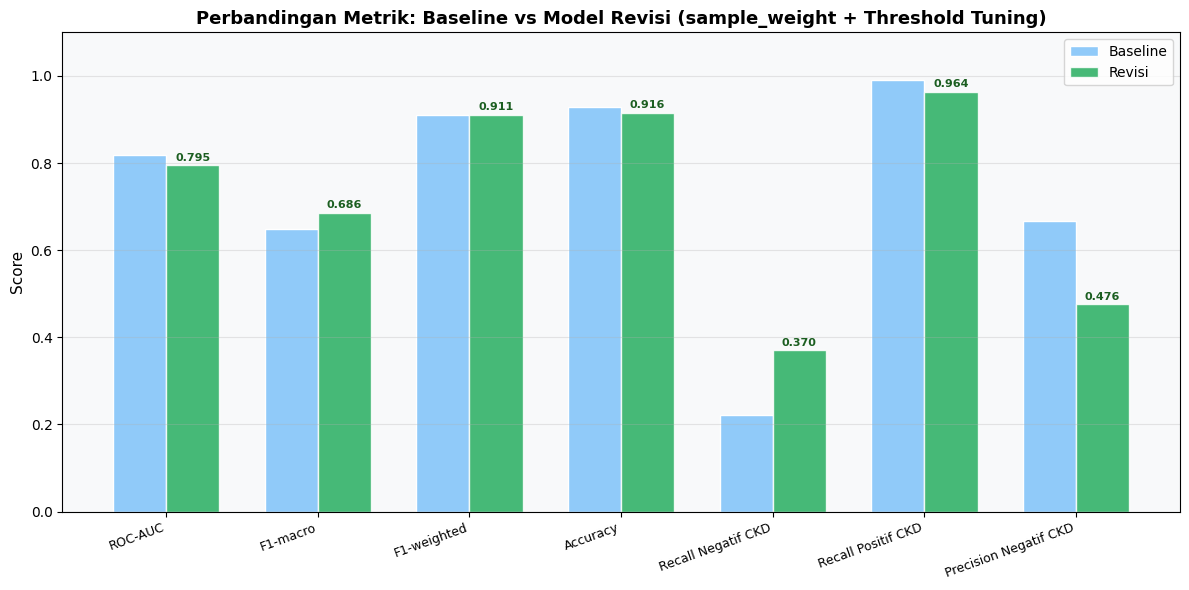

In [54]:
print("=== PERBANDINGAN BASELINE DENGAN REVISI (Test Set) ===")
print(f"{'Metrik':<25} {'Baseline':>12} {'Revisi':>12} {'Δ':>8}")
print("─" * 60)

metrics_compare = {
    'ROC-AUC'              : (roc_auc_score(y_te, y_prob_base),
                              roc_auc_score(y_te, y_prob_final)),
    'F1-macro'             : (f1_score(y_te, y_pred_base, average='macro'),
                              f1_score(y_te, y_pred_final, average='macro')),
    'F1-weighted'          : (f1_score(y_te, y_pred_base, average='weighted'),
                              f1_score(y_te, y_pred_final, average='weighted')),
    'Accuracy'             : (accuracy_score(y_te, y_pred_base),
                              accuracy_score(y_te, y_pred_final)),
    'Recall Negatif CKD'   : (tn_b/(tn_b+fp_b), tn/(tn+fp)),
    'Recall Positif CKD'   : (tp_b/(tp_b+fn_b), tp/(tp+fn)),
    'Precision Negatif CKD': (precision_score(y_te, y_pred_base, pos_label=0, zero_division=0),
                              precision_score(y_te, y_pred_final, pos_label=0, zero_division=0)),
}

for name, (base_val, rev_val) in metrics_compare.items():
    delta = rev_val - base_val
    arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '→')
    print(f"{name:<25} {base_val:>12.4f} {rev_val:>12.4f} {arrow}{abs(delta):>6.4f}")

# Bar chart perbandingan
fig, ax = plt.subplots(figsize=(12, 6))
metric_names  = list(metrics_compare.keys())
base_vals     = [v[0] for v in metrics_compare.values()]
revised_vals  = [v[1] for v in metrics_compare.values()]

x  = np.arange(len(metric_names))
w  = 0.35
b1 = ax.bar(x - w/2, base_vals,    w, label='Baseline',      color='#90CAF9', edgecolor='white')
b2 = ax.bar(x + w/2, revised_vals, w, label='Revisi',        color='#27AE60', edgecolor='white', alpha=0.85)

for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold', color='#1B5E20')

ax.set_xticks(x); ax.set_xticklabels(metric_names, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('Perbandingan Metrik: Baseline vs Model Revisi (sample_weight + Threshold Tuning)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.set_facecolor('#F8F9FA')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 9.13 Kurva ROC & Precision-Recall



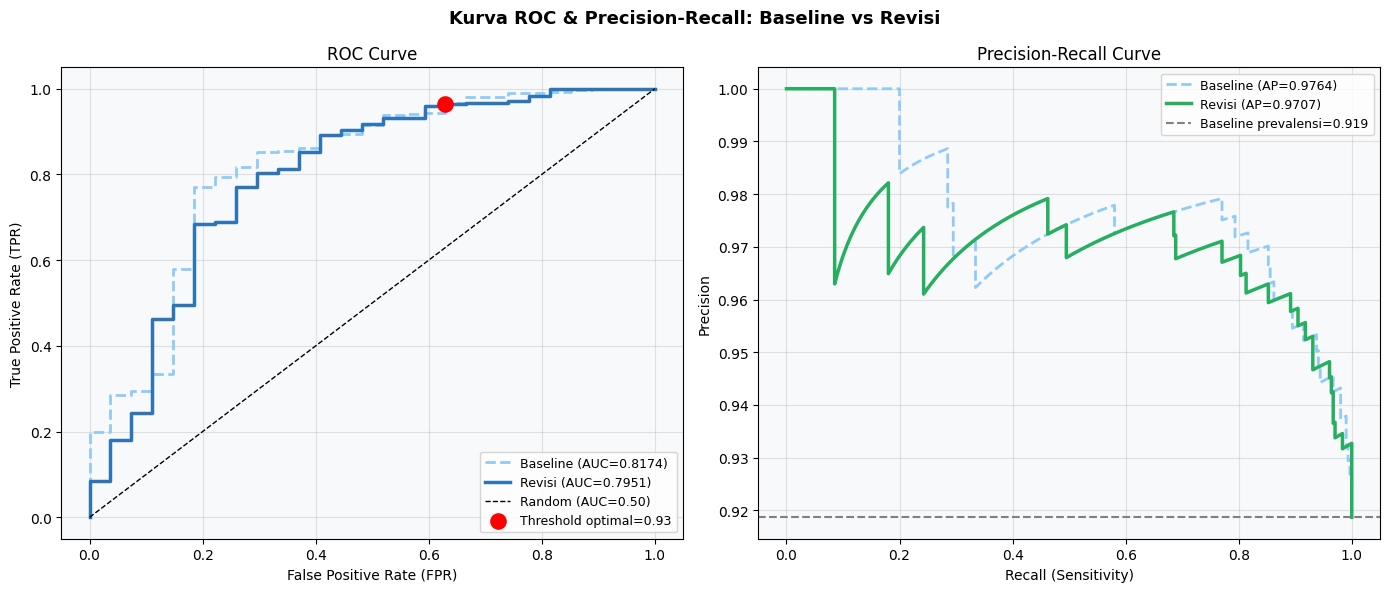

ROC-AUC Baseline : 0.8174
ROC-AUC Revisi   : 0.7951  (Δ -0.0222)
Avg Precision Revisi: 0.9707


In [55]:
fpr_b, tpr_b, _ = roc_curve(y_te, y_prob_base)
fpr_r, tpr_r, thresh_r = roc_curve(y_te, y_prob_final)
auc_b = roc_auc_score(y_te, y_prob_base)
auc_r = roc_auc_score(y_te, y_prob_final)

prec_b, rec_b, _ = precision_recall_curve(y_te, y_prob_base)
prec_r, rec_r, _ = precision_recall_curve(y_te, y_prob_final)
ap_b = average_precision_score(y_te, y_prob_base)
ap_r = average_precision_score(y_te, y_prob_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Kurva ROC & Precision-Recall: Baseline vs Revisi', fontsize=13, fontweight='bold')

# ROC
axes[0].plot(fpr_b, tpr_b, color='#90CAF9', lw=2, ls='--', label=f'Baseline (AUC={auc_b:.4f})')
axes[0].plot(fpr_r, tpr_r, color='#2E75B6', lw=2.5, label=f'Revisi (AUC={auc_r:.4f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC=0.50)')
# Titik threshold optimal
opt_fpr = fp / (fp + tn)
opt_tpr = tp / (tp + fn)
axes[0].scatter(opt_fpr, opt_tpr, color='red', s=120, zorder=5,
                label=f'Threshold optimal={best_thresh:.2f}')
axes[0].set_xlabel('False Positive Rate (FPR)'); axes[0].set_ylabel('True Positive Rate (TPR)')
axes[0].set_title('ROC Curve'); axes[0].legend(fontsize=9)
axes[0].set_facecolor('#F8F9FA'); axes[0].grid(True, alpha=0.35)

# PR Curve
axes[1].plot(rec_b, prec_b, color='#90CAF9', lw=2, ls='--', label=f'Baseline (AP={ap_b:.4f})')
axes[1].plot(rec_r, prec_r, color='#27AE60', lw=2.5, label=f'Revisi (AP={ap_r:.4f})')
axes[1].axhline(y=y_te.mean(), color='gray', ls='--', lw=1.5,
                label=f'Baseline prevalensi={y_te.mean():.3f}')
axes[1].set_xlabel('Recall (Sensitivity)'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend(fontsize=9)
axes[1].set_facecolor('#F8F9FA'); axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

print(f"ROC-AUC Baseline : {auc_b:.4f}")
print(f"ROC-AUC Revisi   : {auc_r:.4f}  (Δ {auc_r-auc_b:+.4f})")
print(f"Avg Precision Revisi: {ap_r:.4f}")

## 9.14 Feature Importance (Permutation)



=== PERMUTATION IMPORTANCE — TOP 15 FITUR ===
Rank  Fitur                                 Importance      Std
──────────────────────────────────────────────────────────────
1     SerumCreatinine                          0.10595  0.03750  ████████████████████
2     GFR                                      0.06077  0.02451  ███████████
3     MuscleCramps                             0.01602  0.01570  ███
4     Itching                                  0.01313  0.01150  ██
5     NauseaVomiting                           0.01145  0.00605  ██
6     HemoglobinLevels                         0.01099  0.00557  ██
7     ProteinInUrine                           0.01072  0.01220  ██
8     BUNLevels                                0.01069  0.01676  ██
9     QualityOfLifeScore                       0.01049  0.00633  █
10    FastingBloodSugar                        0.00922  0.00754  █
11    BMI                                      0.00583  0.00507  █
12    AlcoholConsumption                       0.00520

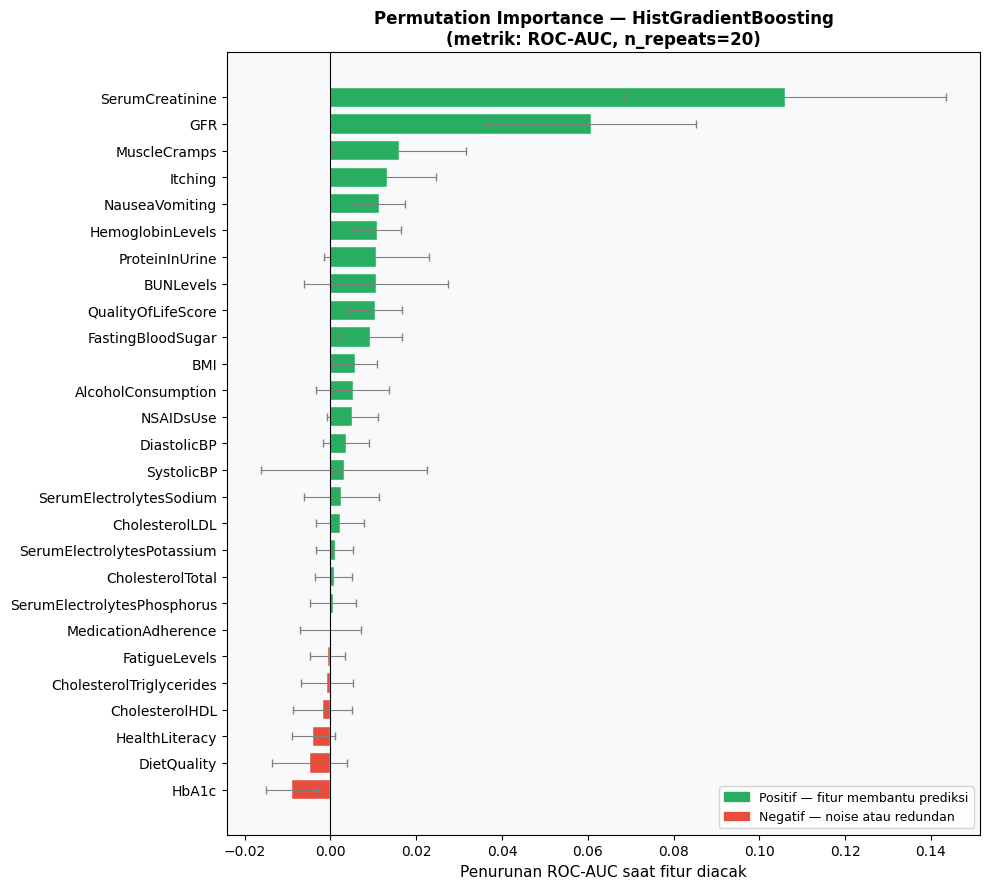

In [56]:
result = permutation_importance(
    clf_final, X_te, y_te,
    n_repeats=20, random_state=42, scoring='roc_auc', n_jobs=-1
)

df_perm = pd.DataFrame({
    'Fitur'     : selected_features,
    'Importance': result.importances_mean,
    'Std'       : result.importances_std
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=== PERMUTATION IMPORTANCE — TOP 15 FITUR ===")
print(f"{'Rank':<5} {'Fitur':<35} {'Importance':>12} {'Std':>8}")
print("─" * 62)
for i, row in df_perm.head(15).iterrows():
    bar = '█' * int(row['Importance'] / df_perm['Importance'].max() * 20)
    print(f"{i+1:<5} {row['Fitur']:<35} {row['Importance']:>12.5f} {row['Std']:>8.5f}  {bar}")

fig, ax = plt.subplots(figsize=(10, 9))
colors_p = ['#27AE60' if v > 0 else '#E74C3C' for v in df_perm['Importance']]
ax.barh(df_perm['Fitur'][::-1], df_perm['Importance'][::-1],
        xerr=df_perm['Std'][::-1], color=colors_p[::-1],
        error_kw={'ecolor':'gray','capsize':3,'linewidth':0.8},
        edgecolor='white', linewidth=0.3, height=0.72)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Permutation Importance — HistGradientBoosting\n(metrik: ROC-AUC, n_repeats=20)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Penurunan ROC-AUC saat fitur diacak', fontsize=11)
ax.set_facecolor('#F8F9FA')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#27AE60', label='Positif — fitur membantu prediksi'),
                   Patch(color='#E74C3C', label='Negatif — noise atau redundan')], fontsize=9)
plt.tight_layout()
plt.show()

## 9.15 Visualisasi: Validation Curve (Overfitting / Underfitting)

Untuk mendiagnosis _overfitting_ atau _underfitting_ pada model dapat membuat _validation curve_. Kurva ini memplot skor performa model (misalnya, ROC-AUC) pada set pelatihan dan set validasi terhadap satu _hyperparameter_ yang diubah-ubah nilainya (dalam kasus ini, max_iter atau jumlah _estimator_).

- **_Underfitting_**: Jika kedua kurva (pelatihan dan validasi) menunjukkan skor rendah, model mungkin terlalu sederhana dan tidak menangkap pola yang relevan dalam data.
- **_Overfitting_**: Jika skor pelatihan sangat tinggi tetapi skor validasi jauh lebih rendah, model mungkin terlalu kompleks dan menghafal data pelatihan beserta _noise_-nya, sehingga performanya buruk pada data baru.
- **_Best-Fitting_**: Titik di mana skor validasi mencapai puncaknya atau stabil, dan celah antara skor pelatihan dan validasi tidak terlalu besar, menunjukkan keseimbangan yang baik antara _bias_ dan _variance_.

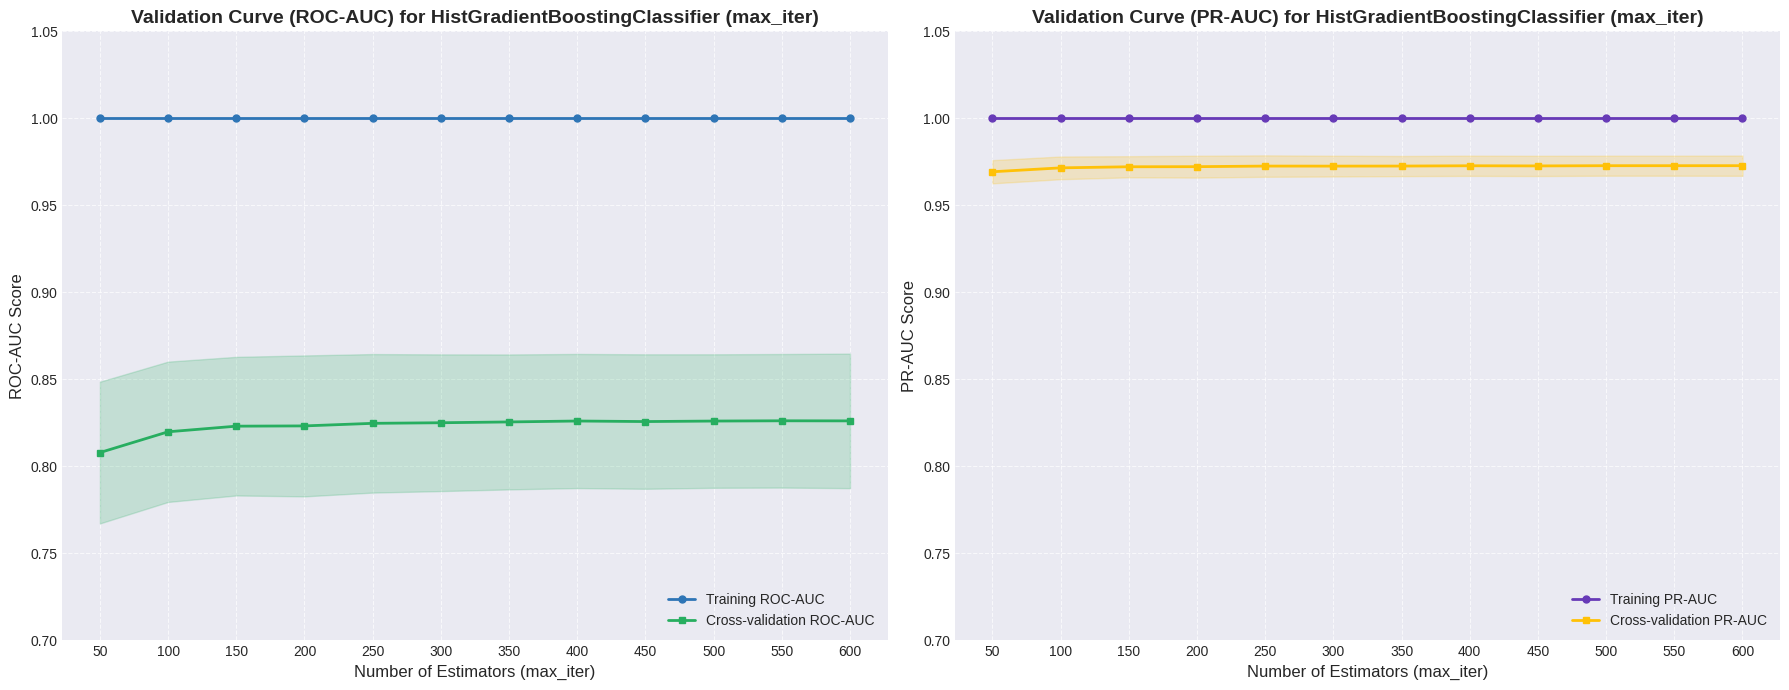


Interpretasi Validation Curve:
  - Kurva solid menunjukkan kinerja pada data latih, kurva putus-putus pada data validasi (Cross-Validation).
  - Jika kurva pelatihan tinggi dan kurva validasi jauh lebih rendah: Overfitting.
  - Jika kedua kurva rendah dan dekat satu sama lain: Underfitting.
  - Jika kedua kurva tinggi dan dekat satu sama lain: Best-fitting, dengan keseimbangan baik.


In [62]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

max_iter_values = np.arange(50, 601, 50)

# Lists for ROC-AUC scores
train_roc_aucs_mean = []
test_roc_aucs_mean = []
train_roc_aucs_std = []
test_roc_aucs_std = []

# Lists for PR-AUC scores
train_pr_aucs_mean = []
test_pr_aucs_mean = []
train_pr_aucs_std = []
test_pr_aucs_std = []

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Loop over each max_iter value
for n_estimators in max_iter_values:
    current_train_roc_aucs = []
    current_test_roc_aucs = []
    current_train_pr_aucs = []
    current_test_pr_aucs = []

    # Iterate through each fold of the cross-validation
    for train_index, val_index in cv_strat.split(X_selected, y_all):
        X_train_fold, X_val_fold = X_selected.iloc[train_index], X_selected.iloc[val_index]
        y_train_fold, y_val_fold = y_all.iloc[train_index], y_all.iloc[val_index]

        # Calculate sample_weights for the current training fold
        neg_count_fold = (y_train_fold == 0).sum()
        pos_count_fold = (y_train_fold == 1).sum()
        if neg_count_fold == 0:
            ratio_fold = 1.0
        else:
            ratio_fold = pos_count_fold / neg_count_fold
        sw_fold = np.where(y_train_fold == 0, ratio_fold, 1.0)

        # Initialize and train the HistGradientBoostingClassifier with current max_iter
        clf = HistGradientBoostingClassifier(
            learning_rate=best_lr,
            max_iter=n_estimators,
            max_depth=best_depth,
            l2_regularization=best_l2,
            random_state=42
        )
        clf.fit(X_train_fold, y_train_fold, sample_weight=sw_fold)

        # Get probabilities for score calculation
        y_train_prob = clf.predict_proba(X_train_fold)[:, 1]
        y_val_prob = clf.predict_proba(X_val_fold)[:, 1]

        # Calculate ROC-AUC scores for training and validation sets
        current_train_roc_aucs.append(roc_auc_score(y_train_fold, y_train_prob))
        current_test_roc_aucs.append(roc_auc_score(y_val_fold, y_val_prob))

        # Calculate PR-AUC scores for training and validation sets
        current_train_pr_aucs.append(average_precision_score(y_train_fold, y_train_prob))
        current_test_pr_aucs.append(average_precision_score(y_val_fold, y_val_prob))

    # Store the mean and standard deviation of ROC-AUC scores
    train_roc_aucs_mean.append(np.mean(current_train_roc_aucs))
    test_roc_aucs_mean.append(np.mean(current_test_roc_aucs))
    train_roc_aucs_std.append(np.std(current_train_roc_aucs))
    test_roc_aucs_std.append(np.std(current_test_roc_aucs))

    # Store the mean and standard deviation of PR-AUC scores
    train_pr_aucs_mean.append(np.mean(current_train_pr_aucs))
    test_pr_aucs_mean.append(np.mean(current_test_pr_aucs))
    train_pr_aucs_std.append(np.std(current_train_pr_aucs))
    test_pr_aucs_std.append(np.std(current_test_pr_aucs))

# Convert lists to NumPy arrays for easier manipulation and plotting
train_roc_aucs_mean = np.array(train_roc_aucs_mean)
test_roc_aucs_mean = np.array(test_roc_aucs_mean)
train_roc_aucs_std = np.array(train_roc_aucs_std)
test_roc_aucs_std = np.array(test_roc_aucs_std)

train_pr_aucs_mean = np.array(train_pr_aucs_mean)
test_pr_aucs_mean = np.array(test_pr_aucs_mean)
train_pr_aucs_std = np.array(train_pr_aucs_std)
test_pr_aucs_std = np.array(test_pr_aucs_std)

# Plotting the Validation Curve
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
plt.style.use('seaborn-v0_8-darkgrid')

# Plot ROC-AUC
axes[0].plot(max_iter_values, train_roc_aucs_mean, label='Training ROC-AUC',
         color='#2E75B6', lw=2, marker='o', markersize=5)
axes[0].fill_between(max_iter_values, train_roc_aucs_mean - train_roc_aucs_std,
                 train_roc_aucs_mean + train_roc_aucs_std, alpha=0.2,
                 color='#2E75B6')

axes[0].plot(max_iter_values, test_roc_aucs_mean, label='Cross-validation ROC-AUC',
         color='#27AE60', lw=2, marker='s', markersize=5)
axes[0].fill_between(max_iter_values, test_roc_aucs_mean - test_roc_aucs_std,
                 test_roc_aucs_mean + test_roc_aucs_std, alpha=0.2,
                 color='#27AE60')

axes[0].set_title('Validation Curve (ROC-AUC) for HistGradientBoostingClassifier (max_iter)',
          fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Estimators (max_iter)', fontsize=12)
axes[0].set_ylabel('ROC-AUC Score', fontsize=12)
axes[0].set_xticks(max_iter_values)
axes[0].set_ylim(0.7, 1.05)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot PR-AUC
axes[1].plot(max_iter_values, train_pr_aucs_mean, label='Training PR-AUC',
         color='#673AB7', lw=2, marker='o', markersize=5)
axes[1].fill_between(max_iter_values, train_pr_aucs_mean - train_pr_aucs_std,
                 train_pr_aucs_mean + train_pr_aucs_std, alpha=0.2,
                 color='#673AB7')

axes[1].plot(max_iter_values, test_pr_aucs_mean, label='Cross-validation PR-AUC',
         color='#FFC107', lw=2, marker='s', markersize=5)
axes[1].fill_between(max_iter_values, test_pr_aucs_mean - test_pr_aucs_std,
                 test_pr_aucs_mean + test_pr_aucs_std, alpha=0.2,
                 color='#FFC107')

axes[1].set_title('Validation Curve (PR-AUC) for HistGradientBoostingClassifier (max_iter)',
          fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Estimators (max_iter)', fontsize=12)
axes[1].set_ylabel('PR-AUC Score', fontsize=12)
axes[1].set_xticks(max_iter_values)
axes[1].set_ylim(0.7, 1.05)
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("\nInterpretasi Validation Curve:")
print("  - Kurva solid menunjukkan kinerja pada data latih, kurva putus-putus pada data validasi (Cross-Validation).")
print("  - Jika kurva pelatihan tinggi dan kurva validasi jauh lebih rendah: Overfitting.")
print("  - Jika kedua kurva rendah dan dekat satu sama lain: Underfitting.")
print("  - Jika kedua kurva tinggi dan dekat satu sama lain: Best-fitting, dengan keseimbangan baik.")

## 9.16 Ringkasan

In [58]:
print("=" * 70)
print("RINGKASAN PIPELINE LENGKAP — PROJECT 1, 2, 3 (REVISI)")
print("=" * 70)
print(f"{'Step':<6} {'Tahap':<35} {'Input':<20} {'Output'}")
print("─" * 70)
print(f"{'P1.1':<6} {'Load & Cleaning':<35} {'CKD.csv':<20} 1659×52")
print(f"{'P1.2':<6} {'EDA':<35} {'1659×52':<20} Insights + Visualisasi")
print(f"{'P1.3':<6} {'IQR Capping':<35} {'1659×52':<20} df_handled")
print(f"{'P1.4':<6} {'StandardScaler':<35} {'1659×52':<20} df_processed")
print(f"{'P2.1':<6} {'SelectFromModel (RF, mean)':<35} {'1659×51':<20} {len(selected_features)} fitur terpilih")
print(f"{'P3.1':<6} {'Train/Test Split (80/20)':<35} {'1659×'+str(len(selected_features)):<20} {len(X_tr)}/{len(X_te)} sampel")
print(f"{'P3.2':<6} {'sample_weight (ratio='+str(round(class_ratio,1))+')':<35} {str(len(X_tr))+'×'+str(len(selected_features)):<20} Bobot imbalance")
print(f"{'P3.3':<6} {'Tuning HistGradBoost':<35} {str(len(X_tr))+'×'+str(len(selected_features)):<20} Best config")
print(f"{'P3.4':<6} {'Threshold Tuning (F1-macro)':<35} {'Test proba':<20} Threshold={best_thresh:.2f}")
print(f"{'P3.5':<6} {'Evaluasi Final':<35} {str(len(X_te))+'×'+str(len(selected_features)):<20} Metrics + Curves")

print()
print("=== HASIL AKHIR MODEL (REVISI) ===")
print(f"Algoritma         : HistGradientBoostingClassifier")
print(f"Penanganan imbalance: sample_weight (bobot kelas 0 = {class_ratio:.2f})")
print(f"Threshold optimal : {best_thresh:.2f}  (optimasi F1-macro)")
print()
print(f"[CV 5-Fold]  ROC-AUC   = {np.mean(cv_auc):.4f} ± {np.std(cv_auc):.4f}")
print(f"[CV 5-Fold]  F1-macro  = {np.mean(cv_f1m):.4f} ± {np.std(cv_f1m):.4f}")
print(f"[CV 5-Fold]  Accuracy  = {np.mean(cv_acc):.4f} ± {np.std(cv_acc):.4f}")
print(f"[CV 5-Fold]  Rec-Neg   = {np.mean(cv_neg_recall):.4f} ± {np.std(cv_neg_recall):.4f}")
print(f"[CV 5-Fold]  Rec-Pos   = {np.mean(cv_pos_recall):.4f} ± {np.std(cv_pos_recall):.4f}")
print()
print(f"[Test Set]   ROC-AUC   = {roc_auc_score(y_te, y_prob_final):.4f}")
print(f"[Test Set]   F1-macro  = {f1_score(y_te, y_pred_final, average='macro'):.4f}")
print(f"[Test Set]   Accuracy  = {accuracy_score(y_te, y_pred_final):.4f}")
print(f"[Test Set]   Rec-Neg   = {tn/(tn+fp):.4f}")
print(f"[Test Set]   Rec-Pos   = {tp/(tp+fn):.4f}")

RINGKASAN PIPELINE LENGKAP — PROJECT 1, 2, 3 (REVISI)
Step   Tahap                               Input                Output
──────────────────────────────────────────────────────────────────────
P1.1   Load & Cleaning                     CKD.csv              1659×52
P1.2   EDA                                 1659×52              Insights + Visualisasi
P1.3   IQR Capping                         1659×52              df_handled
P1.4   StandardScaler                      1659×52              df_processed
P2.1   SelectFromModel (RF, mean)          1659×51              27 fitur terpilih
P3.1   Train/Test Split (80/20)            1659×27              1327/332 sampel
P3.2   sample_weight (ratio=11.3)          1327×27              Bobot imbalance
P3.3   Tuning HistGradBoost                1327×27              Best config
P3.4   Threshold Tuning (F1-macro)         Test proba           Threshold=0.93
P3.5   Evaluasi Final                      332×27               Metrics + Curves

=== HASIL AKHI

In [59]:
# Simpan output
df_results = pd.DataFrame(X_te.values, columns=selected_features)
df_results['y_true']     = y_te.values
df_results['y_pred']     = y_pred_final
df_results['y_prob_CKD'] = y_prob_final

output_clf = 'CKD_Classification_Results_Revised.csv'
df_results.to_csv(output_clf, index=False)

print(f"Hasil klasifikasi disimpan sebagai '{output_clf}'")
print(f"Shape: {df_results.shape[0]} baris x {df_results.shape[1]} kolom")
print()
print("File output yang dihasilkan seluruh pipeline:")
print("1. CKD_Preprocessed_Ready.csv              — output Project 1")
print("2. CKD_Feature_Selected.csv                — output Project 2 (27 fitur)")
print("3. CKD_Classification_Results.csv          — output Project 3")

Hasil klasifikasi disimpan sebagai 'CKD_Classification_Results_Revised.csv'
Shape: 332 baris x 30 kolom

File output yang dihasilkan seluruh pipeline:
1. CKD_Preprocessed_Ready.csv              — output Project 1
2. CKD_Feature_Selected.csv                — output Project 2 (27 fitur)
3. CKD_Classification_Results.csv          — output Project 3
